# MR STAR Simulation of Different Baseline Methods

Author: Amel Docena

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
drive_folder_path = '/content/drive/My Drive/multi_STAR_sim_results'
os.chdir(drive_folder_path)
print(f"Current working directory: {os.getcwd()}")

Mounted at /content/drive
Current working directory: /content/drive/My Drive/multi_STAR_sim_results


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import pandas as pd
import seaborn as sns
import random
import heapq
import math
from collections import defaultdict

In [ ]:
random.seed(42)
np.random.seed(42)

In [ ]:
class Area:
    def __init__(self, id, x, y, decay_rate, F_max=100.0, threshold=50.0):
        self.id = id
        self.x = x
        self.y = y
        self.position = np.array([x, y])
        self.decay_rate = decay_rate
        self.F_max = F_max
        self.threshold = threshold
        self.F = F_max
        self.history = [self.F]
        self.loss_history = [max(0, self.threshold - self.F)]
        self.last_restore_time = -1

    def decay(self, time_elapsed):
        self.F -= self.decay_rate * time_elapsed
        self.F = max(0, self.F)
        self.history.append(self.F)
        self.loss_history.append(max(0, self.threshold - self.F))

    def restore(self, t_now):
        self.F = self.F_max
        self.history.append(self.F)
        self.loss_history.append(max(0, self.threshold - self.F))
        self.last_restore_time = int(t_now)

In [ ]:
class Robot:
    def __init__(self, id, x, y, battery):
        self.id = id
        self.x = x
        self.y = y
        self.position = np.array([x, y])
        self.battery = battery
        self.clock = 0.0
        self.distance_traveled = 0.0
        self.restored_value = 0.0
        self.trajectory = [] #store decisions, (time, area.id)

### Simulate 2D environment

In [ ]:
def create_decay_ranges_over_quadrants(global_range, mode='linear'):
    """
    Splits the global decay range into 4 quadrant-specific ranges.
    mode: 'linear' means evenly sliced intervals.
    """
    min_decay, max_decay = global_range
    intervals = np.linspace(min_decay, max_decay, 5)

    if mode == 'linear':
        return {
            1: (intervals[3], intervals[4]), #fastest
            2: (intervals[2], intervals[3]),
            3: (intervals[1], intervals[2]),
            4: (intervals[0], intervals[1]), #slowest
        }
    else:
        raise NotImplementedError("Only 'linear' mode currently supported.")


##### Quadrant-like

In [ ]:
def generate_quadrant_star_inputs(n_areas, n_robots, env_size, min_dist=5, decay_range=None, seed=None):
    np.random.seed(seed)
    random.seed(seed)

    x_size, y_size = env_size

    if decay_range is None:
        decay_ranges = {
            1: (0.04, 0.05),
            2: (0.04, 0.05),
            3: (0.0004, 0.0005),
            4: (0.0004, 0.0005)
        }
    else:
        decay_ranges = create_decay_ranges_over_quadrants(decay_range)

    quadrants = {
        1: ((0, x_size/2), (y_size/2, y_size)),
        2: ((x_size/2, x_size), (y_size/2, y_size)),
        3: ((0, x_size/2), (0, y_size/2)),
        4: ((x_size/2, x_size), (0, y_size/2)),
    }

    # Compute area allocation
    n_per_quad = n_areas // 4
    leftovers = n_areas % 4
    areas_per_quadrant = {i: n_per_quad for i in range(1, 5)}
    for i in range(1, leftovers + 1):
        areas_per_quadrant[i] += 1

    areas = []
    id_counter = 0

    for q in range(1, 5):
        x_range, y_range = quadrants[q]
        decay_min, decay_max = decay_ranges[q]
        positions = []

        while len(positions) < areas_per_quadrant[q]:
            x = np.random.uniform(*x_range)
            y = np.random.uniform(*y_range)
            position = np.array([x, y])

            if all(np.linalg.norm(position - np.array([px, py])) >= min_dist for px, py in positions):
                decay_rate = np.random.uniform(decay_min, decay_max)
                areas.append(Area(id=id_counter, x=x, y=y, decay_rate=decay_rate))
                positions.append((x, y))
                id_counter += 1

    robots = []
    for i in range(n_robots):
        x, y = np.random.uniform(0, x_size, size=2)
        robots.append(Robot(id=i, x=x, y=y, battery=100))

    return areas, robots

##### Random

In [ ]:
def generate_quadrant_star_inputs_random(n_areas, n_robots, env_size, min_dist=5, decay_range=(0.01, 0.2),seed=None):
    np.random.seed(seed)
    random.seed(seed)

    x_size, y_size = env_size

    quadrants = {
        1: ((0, x_size/2), (y_size/2, y_size)),
        2: ((x_size/2, x_size), (y_size/2, y_size)),
        3: ((0, x_size/2), (0, y_size/2)),
        4: ((x_size/2, x_size), (0, y_size/2)),
    }

    # Distribute number of areas among quadrants
    n_per_quad = n_areas // 4
    leftovers = n_areas % 4
    areas_per_quadrant = {i: n_per_quad for i in range(1, 5)}
    for i in range(1, leftovers + 1):
        areas_per_quadrant[i] += 1

    areas = []
    id_counter = 0

    for q in range(1, 5):
        x_range, y_range = quadrants[q]
        positions = []

        while len(positions) < areas_per_quadrant[q]:
            x = np.random.uniform(*x_range) #TODO: Set the random range
            y = np.random.uniform(*y_range)
            position = np.array([x, y])

            if all(np.linalg.norm(position - np.array([px, py])) >= min_dist for px, py in positions):
                decay_rate = np.random.uniform(*decay_range)
                areas.append(Area(id=id_counter, x=x, y=y, decay_rate=decay_rate))
                positions.append((x, y))
                id_counter += 1

    # Robots randomly anywhere
    robots = []
    for i in range(n_robots):
        x, y = np.random.uniform(0, x_size, size=2)
        robots.append(Robot(id=i, x=x, y=y, battery=100))

    return areas, robots

### Helper functions

In [ ]:
def cluster_areas_by_distance_and_decay(areas, n_clusters, decay_weight=1.0, normalize=True, random_state=42):
    """
    Cluster areas using KMeans based on x, y position and decay rate (with optional weighting).
    """
    features = np.array([[a.x, a.y, a.decay_rate * decay_weight] for a in areas])

    if normalize:
        scaler = StandardScaler()
        features = scaler.fit_transform(features)

    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    labels = kmeans.fit_predict(features)

    cluster_dict = {i: [] for i in range(n_clusters)}
    for i, label in enumerate(labels):
        cluster_dict[label].append(areas[i])

    return cluster_dict

In [ ]:
def compute_total_loss_from_histories(areas, threshold=50.0, fmax=100):
    """
    Compute total loss at each timestep based on the F histories of all areas.
    Loss at time t is the sum over all areas of max(0, F_max - F_t).
    """
    if not areas:
        return []

    T = len(areas[0].history)
    total_losses = []

    for t in range(T):
        loss_t = 0.0
        for a in areas:
            f_t = a.history[t]
            loss_t += max(0, fmax - f_t)
        total_losses.append(loss_t)

    return total_losses


In [ ]:
def compute_cumulative_total_loss(losses):
    cumulative = []
    total = 0.0
    for loss in losses:
        total += loss
        cumulative.append(total)
    return cumulative

In [ ]:
def plot_star_loss_metrics(total_losses, cumulative_losses):
    """
    Plot both cost and cumulative cost over time.
    """
    fig, axs = plt.subplots(2, 1, figsize=(10, 8))

    axs[0].plot(total_losses, color='red')
    axs[0].set_title(f"Cost Over Time")
    axs[0].set_xlabel("Time")
    axs[0].set_ylabel("Cost")

    axs[1].plot(cumulative_losses, color='blue')
    axs[1].set_title(f"Cumulative Cost Over Time")
    axs[1].set_xlabel("Time")
    axs[1].set_ylabel("Cumulative Cost")

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_star_results(areas, robots, fmax=100, thresh=50):
    print("Debugging plot_star_results:")
    print(f"Type of areas: {type(areas)}")
    if isinstance(areas, list):
        print(f"Length of areas list: {len(areas)}")
        if areas:
            print(f"Type of first element in areas: {type(areas[0])}")

    # 1. Plot per-area decay
    plt.figure(figsize=(10, 6))
    for a in areas:
        print(f"Processing area: {a}")
        plt.plot(a.history, label=f"Area {a.id}")
    plt.title(f"Per-Area Decay Over Time")
    plt.axhline(y=thresh, color='r', linestyle='--', label=f'Threshold ({thresh})')
    plt.ylim(0, fmax)
    plt.xlabel("Timestep Index")
    plt.ylabel("Decay Level F")
    plt.legend(ncol=2, fontsize="small")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 2. Plot robot efficiency
    robot_ids = [r.id for r in robots]
    efficiency = [r.restored_value / r.distance_traveled if r.distance_traveled > 0 else 0 for r in robots]

    plt.figure(figsize=(8, 5))
    sns.barplot(x=robot_ids, y=efficiency, palette="Blues")
    plt.title(f"Robot Efficiency (Restored Value / Distance)")
    plt.xlabel("Robot ID")
    plt.ylabel("Efficiency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Method 1: Heirarchical clustering

In [ ]:
def assign_clusters_to_robots(robots, clusters):
    """
    Assign each cluster to the robot closest to its most urgent area.
    Returns a dictionary {robot_id: list of areas}.
    """
    available_robots = robots.copy()
    assignments = {}

    for cluster_id, cluster_areas in clusters.items():
        if not cluster_areas:
            continue
        # Choose most urgent area (lowest F) as anchor
        urgent_area = min(cluster_areas, key=lambda a: a.F)
        # Assign closest available robot to this cluster
        best_robot = min(available_robots, key=lambda r: np.linalg.norm(r.position - urgent_area.position))
        assignments[best_robot.id] = cluster_areas
        available_robots.remove(best_robot)

    return assignments

In [ ]:
def fixed_cluster_assignment(areas, robots, num_robots, alpha_decay=1.0, random_state=42):
    # Construct feature vectors [x, y, α * decay_rate]
    features = []
    for a in areas:
        x, y = a.position
        d = float(getattr(a, "decay_rate", 0.0))
        features.append([x, y, alpha_decay * d])
    features = np.array(features, dtype=float)

    # Cluster by KMeans
    kmeans = KMeans(n_clusters=num_robots, n_init=10, random_state=random_state)
    labels = kmeans.fit_predict(features)

    # Build clusters
    clusters = {i: [] for i in range(num_robots)}
    for area, label in zip(areas, labels):
        clusters[label].append(area)

    # Assign clusters to robots (e.g., by Hungarian or greedy)
    return assign_clusters_to_robots(robots, clusters)


In [ ]:
areas, robots = generate_quadrant_star_inputs(n_areas=12, n_robots=3, seed=42, env_size=(100, 100))
assignments = fixed_cluster_assignment(areas, robots, num_robots=len(robots))

## Method 2: Global greedy

In [ ]:
def global_greedy_callback_builder(k=None):
    """
    Returns a function that can be called as dynamic_assignment_fn(robots, areas, time),
    recomputing assignments at each step.
    """
    def callback(robots, areas, time):
        n_robots = len(robots)
        k_select = k or n_robots

        # Select top-k most decayed areas
        top_areas = sorted(areas, key=lambda a: a.F)[:k_select]

        available_robots = robots.copy()
        assignments = {r.id: [] for r in robots}

        # Assign each area greedily to nearest available robot
        for area in top_areas:
            if not available_robots:
                break
            best_robot = min(available_robots, key=lambda r: np.linalg.norm(r.position - area.position))
            assignments[best_robot.id].append(area)
            available_robots.remove(best_robot)

        return assignments
    return callback


In [ ]:
# Global greedy callback
dynamic_assignment_fn = global_greedy_callback_builder(k=3)

## Method 3: Job-scheduling type

In [ ]:
def job_scheduler_callback_builder():
    """
    Returns a function that can be called as dynamic_assignment_fn(robots, areas, time),
    recomputing assignments at each step based on earliest projected arrival.
    """
    def callback(robots, areas, time):
        assignments = {r.id: [] for r in robots}
        sorted_areas = sorted(areas, key=lambda a: a.F)
        assigned_areas = set()

        for area in sorted_areas:
            if area.id in assigned_areas:
                continue

            best_robot = None
            best_eta = float('inf')

            for r in robots:
                travel_time = np.linalg.norm(r.position - area.position)
                eta = r.clock + travel_time
                if eta < best_eta:
                    best_eta = eta
                    best_robot = r

            if best_robot:
                assignments[best_robot.id].append(area)
                assigned_areas.add(area.id)

        return assignments
    return callback

## Method 4: Mixed Portfolio
We have a category of fast and slow decaying areas. We then create a portfolio mixed with fast and slow decaying areas

In [ ]:
def mixed_portfolio_assignment(areas, robots, num_robots):
    sorted_areas = sorted(areas, key=lambda a: a.decay_rate, reverse=True)
    mid = len(sorted_areas) // 2
    high_risk_areas = sorted_areas[:mid] #TODO: Sort/set threshold by urgency instead
    low_risk_areas  = sorted_areas[mid:]

    clusters = {i: [] for i in range(num_robots)}
    for cluster_id in range(num_robots):
        if high_risk_areas:
            clusters[cluster_id].append(high_risk_areas.pop(0))
        elif low_risk_areas:
            clusters[cluster_id].append(low_risk_areas.pop(0))

    while high_risk_areas or low_risk_areas:
        for cluster_id in range(num_robots):
            cluster = clusters[cluster_id]
            if not cluster:
                continue
            last = cluster[-1]
            toggle_high = len(cluster) % 2 == 1
            candidate_list = high_risk_areas if toggle_high else low_risk_areas
            if not candidate_list:
                candidate_list = low_risk_areas if toggle_high else high_risk_areas
            if not candidate_list:
                continue
            nearest = min(candidate_list, key=lambda a: np.linalg.norm(last.position - a.position))
            cluster.append(nearest)
            candidate_list.remove(nearest)

    return assign_clusters_to_robots(robots, clusters)

## Method 5: Schedule found for a single robot, then distribute.
Break down/distribute to the other robots, pretty much following the order/schedule found by the robot.

In [ ]:
import itertools

In [ ]:
def brute_force_solo_sequence(areas):
    best_cost = float('inf')
    best_sequence = None
    for perm in itertools.permutations(areas):
        cost = sum(np.linalg.norm(perm[i].position - perm[i+1].position)
                   for i in range(len(perm) - 1))
        if cost < best_cost:
            best_cost = cost
            best_sequence = perm
    return list(best_sequence)

In [ ]:
def greedy_solo_sequence(areas):
    unvisited = set(areas)
    current = max(unvisited, key=lambda a: a.decay_rate)
    sequence = [current]
    unvisited.remove(current)
    while unvisited:
        next_area = min(unvisited, key=lambda a: np.linalg.norm(current.position - a.position))
        sequence.append(next_area)
        unvisited.remove(next_area)
        current = next_area
    return sequence

In [ ]:
def split_sequence_evenly(sequence, num_robots):
    chunk_size = int(np.ceil(len(sequence) / num_robots))
    assignments = {}
    for i in range(num_robots):
        start = i * chunk_size
        end = min((i+1) * chunk_size, len(sequence))
        assignments[i] = sequence[start:end]
    return assignments

In [ ]:
def repeated_solo_split_assignment(areas, robots, num_robots, method="greedy"):
    """
    Compute a single global solo route (optimal or greedy)
    and evenly distribute it among robots.
    """
    if method == "brute_force":
        sequence = brute_force_solo_sequence(areas)
    else:
        sequence = greedy_solo_sequence(areas)

    raw_assignments = split_sequence_evenly(sequence, num_robots)

    # Assign based on proximity to first area in their chunk
    available_robots = robots.copy()
    assignments = {}
    for cluster_id, cluster_areas in raw_assignments.items():
        if not cluster_areas:
            continue
        first_area = cluster_areas[0]
        best_robot = min(available_robots, key=lambda r: np.linalg.norm(r.position - first_area.position))
        assignments[best_robot.id] = cluster_areas
        available_robots.remove(best_robot)

    return assignments

In [ ]:
assignments = repeated_solo_split_assignment(areas, robots, num_robots=len(robots), method="greedy")

## Method 5: MDP

In [ ]:
!pip install mdpsolver
import mdpsolver

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.7 MB/s eta 0:00:00


In [ ]:
import numpy as np, math, copy
from typing import Dict, List, Tuple, Optional

### Exact MDP

We implemented an Exact MDP using MDP Solver, but even for a small-sized problem, it was already intractable.

In [ ]:
def _build_bins(F_max: float, bin_size: float) -> np.ndarray:
    edges = np.arange(0, F_max + 1e-9, bin_size, dtype=float)
    if edges[-1] < F_max - 1e-9:
        edges = np.append(edges, F_max)
    return edges

def _bin_index(F: float, edges: np.ndarray) -> int:
    return int(np.clip(np.searchsorted(edges, F, side="right") - 1, 0, len(edges)-1))

def _unbin(idx: int, edges: np.ndarray) -> float:
    return float(edges[int(np.clip(idx, 0, len(edges)-1))])

def _instant_loss(F_list: List[float], thresholds: List[float]) -> float:
    return sum(max(0.0, thresholds[j] - F_list[j]) for j in range(len(F_list)))

In [ ]:
def _simulate_joint_assignment_event_driven(F0: List[float], deltas: List[float],
                                            thresholds: List[float],
                                            robot_nodes: List[int],
                                            area_pos: List[np.ndarray],
                                            targets: List[int],
                                            velocity: float,
                                            F_max: float) -> Tuple[List[float], List[int], float, int]:
    """
    Simulate a single joint assignment epoch exactly like simulate_star's coalesced arrivals.
    Returns: (F_next, robot_nodes_next, total_loss_saved, tau_max)
    """
    R = len(robot_nodes)
    # Distances & arrival steps per robot
    taus = []
    for r in range(R):
        dist = float(np.linalg.norm(area_pos[robot_nodes[r]] - area_pos[targets[r]]))
        tau = int(math.ceil(dist / max(1e-12, velocity)))
        taus.append(tau)
    unique_events = sorted(set([t for t in taus if t > 0]))
    F = F0[:]
    total_saved = 0.0
    time_elapsed = 0
    if not unique_events:
        # All arrivals immediate
        pre = _instant_loss(F, thresholds)
        for r in range(R):
            F[targets[r]] = F_max
        post = _instant_loss(F, thresholds)
        total_saved += max(0.0, pre - post)
        tau_max = 0
        return F, targets[:], total_saved, tau_max
    # Step through arrival events
    for ev in unique_events:
        # decay until this arrival
        span = ev - time_elapsed
        for _ in range(span):
            for j in range(len(F)):
                F[j] = max(0.0, F[j] - deltas[j])
        time_elapsed = ev
        # restore all robots that arrive now
        pre = _instant_loss(F, thresholds)
        for r in range(R):
            if taus[r] == ev:
                F[targets[r]] = F_max
        post = _instant_loss(F, thresholds)
        total_saved += max(0.0, pre - post)
    tau_max = max(taus) if taus else 0
    # decay from last event to tau_max (no more restores)
    if time_elapsed < tau_max:
        for _ in range(tau_max - time_elapsed):
            for j in range(len(F)):
                F[j] = max(0.0, F[j] - deltas[j])
    return F, targets[:], total_saved, tau_max

In [ ]:
def build_star_mdp_matrices_for_mdpsolver(areas, robots, velocity=1.0, F_max=100.0,
                                          bin_size=10.0, gamma=0.99,
                                          alpha_move=0.0):
    """
    Enumerate a tiny STAR MDP and build (rewards, tranMatElementwise) for mdpsolver.
    Returns a dict with mdp arrays and index maps.
    """
    N = len(areas); R = len(robots)
    edges = _build_bins(F_max, bin_size)
    area_pos = [a.position.copy() for a in areas]
    deltas = [float(a.decay_rate) for a in areas]
    thresholds = [float(a.threshold) for a in areas]
    area_ids = [int(a.id) for a in areas]
    # State space: robot_nodes (indices 0..N-1 per robot) × F_bins (0..B-1 per area)
    robot_nodes_all = list(itertools.product(range(N), repeat=R))
    Fbins_all = list(itertools.product(range(len(edges)), repeat=N))
    states = []
    for rn in robot_nodes_all:
        for fb in Fbins_all:
            states.append((tuple(rn), tuple(fb)))
    S = len(states)
    s_index = {states[i]: i for i in range(S)}
    # Action space: joint assignments targets per robot (0..N-1)^R
    actions = list(itertools.product(range(N), repeat=R))
    A = len(actions)
    a_index = {actions[i]: i for i in range(A)}
    # Build rewards[S][A] and sparse transitions elementwise [from_s, a, to_s, prob]
    rewards = [[0.0 for _ in range(A)] for __ in range(S)]
    tran_elts = []
    for si, (robot_nodes, Fbins) in enumerate(states):
        F_cont = [ _unbin(b, edges) for b in Fbins ]
        for ai, targets in enumerate(actions):
            # Travel penalty
            move_pen = 0.0
            for r in range(R):
                dist = float(np.linalg.norm(area_pos[robot_nodes[r]] - area_pos[targets[r]]))
                move_pen += alpha_move * dist
            F_next_cont, robot_nodes_next, saved, tau_max = _simulate_joint_assignment_event_driven(
                F_cont, deltas, thresholds, list(robot_nodes), area_pos, list(targets), velocity, F_max
            )
            # Reward per epoch = total loss saved minus travel penalty
            r_sa = float(saved) - float(move_pen)
            # Next state bins
            Fbins_next = tuple(_bin_index(F_next_cont[j], edges) for j in range(N))
            s_next = s_index[(tuple(robot_nodes_next), Fbins_next)]
            rewards[si][ai] = r_sa
            tran_elts.append([si, ai, s_next, 1.0])  # deterministic
    return {
        "edges": edges,
        "states": states,
        "actions": actions,
        "s_index": s_index,
        "a_index": a_index,
        "rewards": rewards,
        "tranMatElementwise": tran_elts,
    }

In [ ]:
def mdpsolver_policy_callback_multi_robot(areas_init, robots_init, velocity=1.0,
                                          F_max=100.0, bin_size=10.0, gamma=0.99,
                                          alpha_move=0.0):
    """
    Solve the tiny enumerated STAR MDP with mdpsolver and return a dynamic planner callback.

    """
    comps = build_star_mdp_matrices_for_mdpsolver(
        areas_init, robots_init, velocity=velocity, F_max=F_max,
        bin_size=bin_size, gamma=gamma, alpha_move=alpha_move
    )
    mdl = mdpsolver.model()
    mdl.mdp(discount=gamma,
            rewards=comps["rewards"],
            tranMatElementwise=comps["tranMatElementwise"])
    mdl.solve()
    pol = mdl.getPolicy()  # list of best action index per state_index
    # Reverse maps
    states = comps["states"]; actions = comps["actions"]
    edges = comps["edges"]
    def _bin_idx(F): return int(np.clip(np.searchsorted(edges, F, side="right") - 1, 0, len(edges)-1))
    def dyn_fn(robots, areas, t_now) -> Dict[int, int]:
        # Form current enumerated state (snap robots to nearest area; bin current F)
        robot_nodes = []
        for r in robots:
            dists = [float(np.linalg.norm(r.position - a.position)) for a in areas]
            robot_nodes.append(int(np.argmin(dists)))
        Fbins = tuple(_bin_idx(float(a.F)) for a in areas)
        s = (tuple(robot_nodes), Fbins)
        # Find nearest known state by clamping bins (if size mismatch due to area ordering differences)
        # Here we assume same ordering and sizes as the initial build.
        try:
            si = comps["s_index"][s]
            ai = int(pol[si])
            targets = actions[ai]
            return {robots[i].id: areas[targets[i]].id for i in range(len(robots))}
        except KeyError:
            # Fallback: greedy instantaneous-loss assignment to keep sim running
            assignment = {}
            used = set()
            for i, r in enumerate(robots):
                best_val, best_j = -1e18, 0
                for j, a in enumerate(areas):
                    if j in used:
                        continue
                    dist = float(np.linalg.norm(r.position - a.position))
                    tau = int(math.ceil(dist / max(1e-12, velocity)))
                    Fpred = max(0.0, float(a.F) - float(a.decay_rate) * tau)
                    val = max(0.0, float(a.threshold) - Fpred)
                    if val > best_val:
                        best_val, best_j = val, j
                used.add(best_j)
                assignment[robots[i].id] = areas[best_j].id
            return assignment
    return dyn_fn

### Approximate MDP

Since the exact MDP was intractable in trials, we built an approximate MDP in lieu.

In [ ]:
def _instant_loss(F_list: List[float], thresholds: List[float]) -> float:
    return sum(max(0.0, thresholds[j] - F_list[j]) for j in range(len(F_list)))

def _simulate_joint_assignment_event_driven(F0: List[float], deltas: List[float],
                                            thresholds: List[float],
                                            robot_nodes: List[int],
                                            area_pos: List[np.ndarray],
                                            targets: List[int],
                                            velocity: float,
                                            F_max: float) -> Tuple[List[float], List[int], float, int, float]:
    """
    Simulate one joint assignment epoch (like simulate_star's coalesced arrivals).
    """
    R = len(robot_nodes)
    taus = []
    travel_cost = 0.0
    for r in range(R):
        dist = float(np.linalg.norm(area_pos[robot_nodes[r]] - area_pos[targets[r]]))
        travel_cost += dist
        tau = int(math.ceil(dist / max(1e-12, velocity)))
        taus.append(tau)
    unique_events = sorted(set([t for t in taus if t > 0]))
    F = F0[:]
    total_saved = 0.0
    time_elapsed = 0
    if not unique_events:
        pre = _instant_loss(F, thresholds)
        for r in range(R):
            F[targets[r]] = F_max
        post = _instant_loss(F, thresholds)
        total_saved += max(0.0, pre - post)
        tau_max = 0
        return F, targets[:], total_saved, tau_max, travel_cost
    for ev in unique_events:
        span = ev - time_elapsed
        for _ in range(span):
            for j in range(len(F)):
                F[j] = max(0.0, F[j] - deltas[j])
        time_elapsed = ev
        pre = _instant_loss(F, thresholds)
        for r in range(R):
            if taus[r] == ev:
                F[targets[r]] = F_max
        post = _instant_loss(F, thresholds)
        total_saved += max(0.0, pre - post)
    tau_max = max(taus) if taus else 0
    if time_elapsed < tau_max:
        for _ in range(tau_max - time_elapsed):
            for j in range(len(F)):
                F[j] = max(0.0, F[j] - deltas[j])
    return F, targets[:], total_saved, tau_max, travel_cost

def _benefit_matrix(robots, areas, velocity: float, alpha_move: float) -> np.ndarray:
    R, N = len(robots), len(areas)
    thresholds = [float(a.threshold) for a in areas]
    benefit = np.zeros((R, N), dtype=float)
    for ri, r in enumerate(robots):
        for j, a in enumerate(areas):
            dist = float(np.linalg.norm(r.position - a.position))
            tau = int(math.ceil(dist / max(1e-12, velocity)))
            Fpred = max(0.0, float(a.F) - float(a.decay_rate) * tau)
            loss_saved = max(0.0, thresholds[j] - Fpred)
            benefit[ri, j] = loss_saved - alpha_move * dist
    return benefit

def _hungarian_assign_from_benefit(benefit: np.ndarray) -> List[int]:
    R, N = benefit.shape
    dim = max(R, N)
    cost = np.zeros((dim, dim), dtype=float)
    cost[:R, :N] = -benefit  # maximize benefit
    rows, cols = linear_sum_assignment(cost)
    targets = [-1]*R
    for r, c in zip(rows, cols):
        if r < R and c < N and benefit[r, c] > -1e18:
            targets[r] = c
    return targets


def _top_indices_by_row(benefit: np.ndarray, topk: int) -> List[List[int]]:
    R, N = benefit.shape
    idxs = []
    for r in range(R):
        order = np.argsort(-benefit[r, :])
        idxs.append(list(order[:min(topk, N)]))
    return idxs

def _candidate_assignments(benefit: np.ndarray, per_robot_top: int) -> List[List[int]]:
    """
    Generate a small set of candidate joint assignments.
    - Baseline Hungarian on full matrix
    - For each robot r, force r to each of its top-(per_robot_top) areas and re-solve Hungarian for others.
    """
    R, N = benefit.shape
    base = _hungarian_assign_from_benefit(benefit)
    cands = [base]
    top_idxs = _top_indices_by_row(benefit, per_robot_top)
    for r in range(R):
        for c in top_idxs[r]:
            if base[r] == c:
                continue
            b = benefit.copy()
            # Force r->c by suppressing other columns in row r
            b[r, :] = -1e18
            b[r, c] = benefit[r, c]
            forced = _hungarian_assign_from_benefit(b)
            if forced not in cands:
                cands.append(forced)
    # Filter invalid rows (some -1 if not enough columns). Keep only those mapping every robot.
    cands = [cand for cand in cands if all(x >= 0 for x in cand)]
    return cands

def mdp_k_step_rollout_callback_builder(k: int = 2,
                                        velocity: float = 1.0,
                                        alpha_move: float = 0.0,
                                        gamma: float = 0.98,
                                        per_robot_top: int = 2) -> callable:
    """
    Return a dynamic_assignment_fn with k-step rollout (k=1 falls back to greedy baseline).

    Parameters
    ----------
    k : int
        Lookahead in number of joint assignment epochs (>=1). k=1 == greedy.
    velocity : float
    alpha_move : float
        Weight for travel distance penalty inside rollout and scoring.
    gamma : float
        Discount per assignment epoch; cumulative discount uses gamma^(sum of epoch durations).
    per_robot_top : int
        How many top areas per robot to consider when generating candidate first actions.
    """
    def dyn_fn(robots, areas, t_now) -> Dict[int, int]:
        if len(robots) == 0 or len(areas) == 0:
            return {}
        R, N = len(robots), len(areas)
        thresholds = [float(a.threshold) for a in areas]
        deltas = [float(a.decay_rate) for a in areas]
        area_pos = [a.position.copy() for a in areas]
        F_max = float(areas[0].F_max) if hasattr(areas[0], "F_max") else 100.0

        # Robot nodes are nearest area indices
        robot_nodes0 = []
        for r in robots:
            dists = [float(np.linalg.norm(r.position - a.position)) for a in areas]
            robot_nodes0.append(int(np.argmin(dists)))
        F0 = [float(a.F) for a in areas]

        # Build candidates for the FIRST assignment
        benefit0 = _benefit_matrix(robots, areas, velocity, alpha_move)
        candidates = _candidate_assignments(benefit0, per_robot_top=max(1, int(per_robot_top)))
        if not candidates:
            return {}

        def rollout_value(first_targets: List[int]) -> float:
            global _tmp_areas
            # Simulate k epochs starting with 'first_targets', then greedy Hungarian thereafter
            total = 0.0
            disc = 1.0
            F = F0[:]
            robot_nodes = robot_nodes0[:]
            for step in range(k):
                if step == 0:
                    targets = first_targets
                else:
                    # Greedy/Hungarian for future steps
                    # fabricate temporary robots at area positions 'robot_nodes'
                    class _TmpR: pass
                    tmp_robots = []
                    for rn in robot_nodes:
                        tr = _TmpR()
                        tr.position = area_pos[rn]
                        tmp_robots.append(tr)
                    B = _benefit_matrix(tmp_robots, _tmp_areas, velocity, alpha_move)
                    targets = _hungarian_assign_from_benefit(B)
                    if any(t < 0 for t in targets):
                        break
                F, robot_nodes, saved, tau_max, travel_cost = _simulate_joint_assignment_event_driven(
                    F, deltas, thresholds, robot_nodes, area_pos, targets, velocity, F_max
                )
                total += disc * (saved - alpha_move * travel_cost)
                disc *= (gamma ** max(1, int(tau_max)))
                # Prepare temporary areas for next-step scoring (updated F)
                # Build a light wrapper with fields .position, .F, .decay_rate, .threshold
                _tmp_areas = []
                for j in range(N):
                    class _A: pass
                    a = _A()
                    a.position = area_pos[j]
                    a.F = F[j]
                    a.decay_rate = deltas[j]
                    a.threshold = thresholds[j]
                    _tmp_areas.append(a)
            return float(total)

        # Evaluate all candidates and pick the best
        best_val, best = -1e18, candidates[0]
        for cand in candidates:
            v = rollout_value(cand)
            if v > best_val:
                best_val, best = v, cand

        # Return mapping from robot.id to chosen area.id (by current ordering)
        return {robots[r].id: areas[best[r]].id for r in range(R)}
    return dyn_fn

## Simulator

In [ ]:
def simulate_star(assignments=None, areas=None, robots=None, T=1000,
                  F_max=100.0, velocity=1.0, dynamic_assignment_fn=None):
    """
    Batch, time-stepped simulator that COALESCES simultaneous arrivals.
    Records runtime stats when the planner returns them
    (i.e., Crisis Mitigation callback returns 4-tuple).
    """
    time = 0
    for r in robots:
        r.clock = 0.0
        r.distance_traveled = 0.0
        r.restored_value = 0.0
        r.trajectory = [r.position.copy()]

    id2area = {int(a.id): a for a in areas}

    # Runtime accumulators (only used if planner provides them)
    runtime_stats = defaultdict(list)  # keys: 'jurisdiction', 'crisis_detection', 'crisis_mitigation'

    def _normalize_to_next_area(entry):
        """Area | int | iterable[Area|int] | None -> Area or None (min-F if iterable)."""
        if entry is None:
            return None
        if hasattr(entry, "id") and hasattr(entry, "position"):
            return entry
        if isinstance(entry, (int, np.integer)):
            return id2area.get(int(entry))
        if isinstance(entry, (list, tuple, set)):
            cands = []
            for e in entry:
                if hasattr(e, "id") and hasattr(e, "position"):
                    cands.append(e)
                elif isinstance(e, (int, np.integer)):
                    a = id2area.get(int(e))
                    if a is not None:
                        cands.append(a)
            return min(cands, key=lambda a: a.F) if cands else None
        return None

    def _get_plan(t_now):
        if dynamic_assignment_fn is not None:
            d = dynamic_assignment_fn(robots, areas, t_now)
            return d or {}
        if callable(assignments):
            d = assignments(robots, areas, t_now)
            return d or {}
        return assignments or {}

    while time < T:
        # 1) Query planner and build one task per robot
        current_assignments = _get_plan(time)

        # --- Handle planners returning runtimes (Crisis Mitigation only) ---
        if isinstance(current_assignments, tuple) and len(current_assignments) == 4:
            current_assignments, j_time, cd_time, cm_time = current_assignments
            runtime_stats["jurisdiction"].append(j_time)
            runtime_stats["crisis_detection"].append(cd_time)
            runtime_stats["crisis_mitigation"].append(cm_time)

        robot_tasks = []  # tuples: (arrival_step:int, robot, target_area, travel_dist)
        for r in robots:
            entry = current_assignments.get(r.id, None)
            target = _normalize_to_next_area(entry)
            if target is None:
                continue
            dist = np.linalg.norm(r.position - target.position)
            arrival_step = min(int(np.ceil(time + dist / max(1e-12, velocity))), T)
            robot_tasks.append((arrival_step, r, target, dist))

        if not robot_tasks:
            # No tasks → advance one step of decay
            for a in areas:
                a.decay(1)
            time += 1
            continue

        # 2) Group tasks by arrival timestep and process in increasing time
        robot_tasks.sort(key=lambda x: x[0])
        groups = defaultdict(list)
        for arr_step, r, tgt, dist in robot_tasks:
            groups[arr_step].append((r, tgt, dist))

        for arr_step in sorted(groups.keys()):
            if time >= T:
                break

            # Advance decay up to this group's arrival timestep (once)
            steps = max(0, min(arr_step, T) - time)
            for _ in range(steps):
                if time >= T:
                    break
                for a in areas:
                    a.decay(1)
                time += 1
            if time >= T:
                break

            # Restore all targets in this group simultaneously
            for r, target_area, dist in groups[arr_step]:
                restored_value = F_max - target_area.F
                target_area.restore(time)
                r.position = target_area.position.copy()
                r.trajectory.append((time, target_area.id))
                r.distance_traveled += dist
                r.restored_value += restored_value
                r.clock = time

    # Trim histories to exactly T
    for a in areas:
        a.history = a.history[:T]
        a.loss_history = a.loss_history[:T]

    # ---- Summarize runtime stats (if any) ----
    if runtime_stats:
        runtime_summary = {
            k: float(np.mean(v)) if v else 0.0 for k, v in runtime_stats.items()
        }
        return areas, robots, runtime_summary

    return areas, robots


## Comparing Methods

In [ ]:
import copy
import matplotlib.pyplot as plt

In [ ]:
def batch_experiments_collect_losses(n_trials=10, n_areas=12, n_robots=3, T=1000, env_size=(100,100), min_dist=5, decay_range=(0.10, 0.30), generate_inputs_func=generate_quadrant_star_inputs):
    methods = ['H-BFVG', 'Mixed Portfolio', 'Solo Distributed', 'Global Greedy', 'Job Scheduling', 'MDP']
    all_losses = {m: [] for m in methods}

    for trial in range(n_trials):
        seed = trial

        original_areas, original_robots = generate_inputs_func(
            n_areas=n_areas,
            n_robots=n_robots,
            env_size=env_size,
            min_dist=min_dist,
            decay_range=decay_range,
            seed=seed
        )

        # Clustering
        areas = copy.deepcopy(original_areas)
        robots = copy.deepcopy(original_robots)
        assignments = fixed_cluster_assignment(areas, robots, n_robots)
        areas_fc, _ = simulate_star(assignments, areas, robots, T=T)
        cumulative_fc = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_fc))
        all_losses['H-BFVG'].append(cumulative_fc)

        # Mixed Portfolio
        areas = copy.deepcopy(original_areas)
        robots = copy.deepcopy(original_robots)
        assignments = mixed_portfolio_assignment(areas, robots, n_robots)
        areas_mp, _ = simulate_star(assignments, areas, robots, T=T)
        cumulative_mp = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_mp))
        all_losses['Mixed Portfolio'].append(cumulative_mp)

        # Repeated Solo
        areas = copy.deepcopy(original_areas)
        robots = copy.deepcopy(original_robots)
        assignments = repeated_solo_split_assignment(areas, robots, n_robots)
        areas_rs, _ = simulate_star(assignments, areas, robots, T=T)
        cumulative_rs = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_rs))
        all_losses['Solo Distributed'].append(cumulative_rs)

        # Global Greedy
        areas = copy.deepcopy(original_areas)
        robots = copy.deepcopy(original_robots)
        dyn_fn = global_greedy_callback_builder(k=n_robots)
        areas_gg, _ = simulate_star(dyn_fn, areas, robots, T=T)
        cumulative_gg = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_gg))
        all_losses['Global Greedy'].append(cumulative_gg)

        # Job Scheduling
        areas = copy.deepcopy(original_areas)
        robots = copy.deepcopy(original_robots)
        dyn_fn = job_scheduler_callback_builder()
        areas_js, _ = simulate_star(dyn_fn, areas, robots, T=T)
        cumulative_js = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_js))
        all_losses['Job Scheduling'].append(cumulative_js)

        # MDP
        areas = copy.deepcopy(original_areas)
        robots = copy.deepcopy(original_robots)
        dyn_fn = mdp_k_step_rollout_callback_builder(k=3, velocity=1.0, alpha_move=0.0, gamma=0.98, per_robot_top=2)
        areas_ro, robots_ro = simulate_star(dynamic_assignment_fn=dyn_fn,
                                            areas=areas,
                                            robots=robots,
                                            T=T, F_max=100.0, velocity=1.0)

        cum_loss_ro = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_ro))
        all_losses['MDP'].append(cum_loss_ro)

        #Insert save of results here

    return all_losses

In [ ]:
def plot_cumulative_loss_with_error(all_losses, T=1000):
    plt.figure(figsize=(10,6))
    for method, trials in all_losses.items():
        losses = np.array(trials)  # shape: (n_trials, T)
        mean_loss = losses.mean(axis=0)
        std_loss = losses.std(axis=0)

        plt.plot(mean_loss, label=method)
        plt.fill_between(range(T), mean_loss - std_loss, mean_loss + std_loss, alpha=0.2)

    plt.xlabel("Time")
    plt.ylabel("Cumulative Total Loss")
    plt.title("Average & Std Dev of Cumulative Total Loss over {} Trials".format(losses.shape[0]))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### Quadrant spatially correlated areas

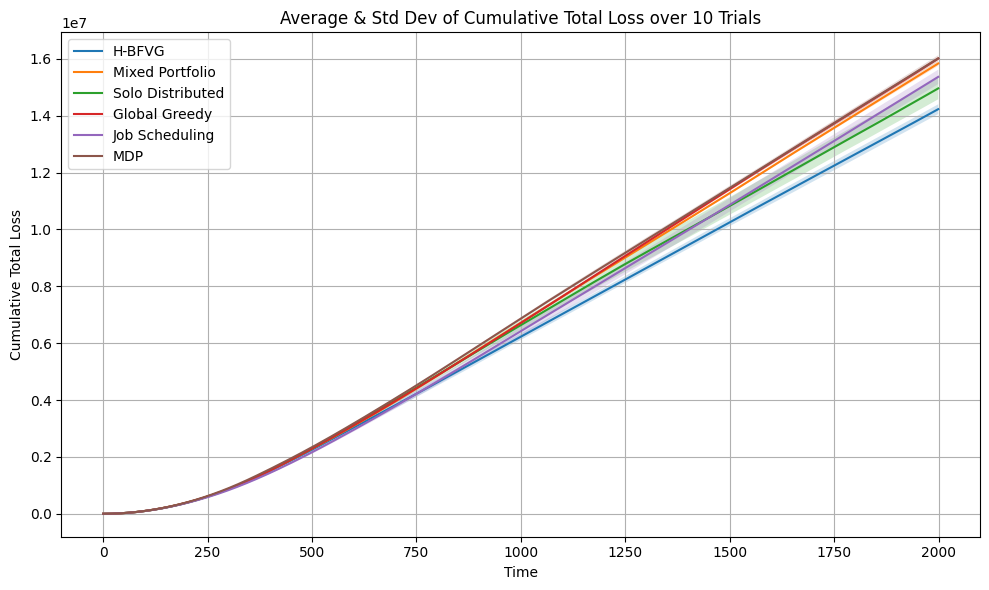

In [ ]:
all_losses = batch_experiments_collect_losses(n_trials=10, n_areas=100, n_robots=10, env_size=(500, 500), T=2000)
plot_cumulative_loss_with_error(all_losses, T=2000)

In [ ]:
all_losses = batch_experiments_collect_losses(n_trials=10, n_areas=100, n_robots=10, T=1000, env_size=(500, 500))
plot_cumulative_loss_with_error(all_losses, T=1000)

#### Randomly placed areas and decay rates

In [ ]:
all_losses_r = batch_experiments_collect_losses(n_trials=10, n_areas=20, n_robots=4, T=1000, generate_inputs_func=generate_quadrant_star_inputs_random)
plot_cumulative_loss_with_error(all_losses_r, T=1000)

#### Metrics

In [ ]:
def batch_experiments_collect_metrics(
    n_trials=10, n_areas=12, n_robots=3, T=1000,
    env_size=(100,100), min_dist=5, decay_range=(0.10, 0.30),
    z=50.0, F_max=100.0,
    generate_inputs_func=generate_quadrant_star_inputs
):
    methods = [
        ('H-BFVG', fixed_cluster_assignment, {}),
        ('Mixed Portfolio', mixed_portfolio_assignment, {}),
        ('Solo Distributed', repeated_solo_split_assignment, {}),
        ('Global Greedy', global_greedy_callback_builder, {'k': n_robots}),
        ('Job Scheduling', job_scheduler_callback_builder, {}),
        ('MDP', mdp_k_step_rollout_callback_builder,
            {'k': 3, 'velocity': 1.0, 'alpha_move': 0.0, 'gamma': 0.98, 'per_robot_top': 2})
    ]

    all_losses = {m[0]: [] for m in methods}
    all_Fs = {m[0]: [] for m in methods}
    all_below_durations = {m[0]: [] for m in methods}

    # Helper
    def compute_weighted_below_threshold_durations(F_matrix, z):
        """
        Weighted average duration below threshold across all areas.
        Weight = 1 / (number of events + eps) so frequent dips are penalized.
        """
        eps = 1e-6
        mean_durations, counts = [], []

        for f_vals in F_matrix:
            below = np.array(f_vals) <= z
            current_len = 0
            durations_i = []
            count_i = 0

            for val in below:
                if val:
                    current_len += 1
                elif current_len > 0:
                    durations_i.append(current_len)
                    count_i += 1
                    current_len = 0
            if current_len > 0:  # ended below threshold
                durations_i.append(current_len)
                count_i += 1

            if durations_i:
                mean_durations.append(np.mean(durations_i))
                counts.append(count_i)

        if not mean_durations:
            return 0.0, 0.0

        mean_durations = np.array(mean_durations, dtype=float)
        counts = np.array(counts, dtype=float)

        weighted = mean_durations / (counts + eps)
        return np.mean(weighted), np.std(weighted)

    # Run trials
    for trial in range(n_trials):
        seed = trial
        original_areas, original_robots = generate_inputs_func(
            n_areas=n_areas, n_robots=n_robots,
            env_size=env_size, min_dist=min_dist,
            decay_range=decay_range, seed=seed
        )

        for name, fn, kwargs in methods:
            areas = copy.deepcopy(original_areas)
            robots = copy.deepcopy(original_robots)

            # Choose whether it's static or dynamic assignment
            if 'callback' in fn.__name__:
                dyn_fn = fn(**kwargs)
                areas_after, _ = simulate_star(
                    dynamic_assignment_fn=dyn_fn,
                    areas=areas, robots=robots, T=T, F_max=F_max, velocity=1.0
                )
            else:
                assignments = fn(areas, robots, n_robots)
                areas_after, _ = simulate_star(
                    assignments, areas, robots, T=T
                )

            # Metrics
            # 1. Cumulative loss
            cumulative_loss = compute_cumulative_total_loss(
                compute_total_loss_from_histories(areas_after)
            )
            all_losses[name].append(cumulative_loss)

            # 2. F histories
            F_matrix = [np.array(getattr(a, "history", []), dtype=float) for a in areas_after]
            F_pad = np.vstack([
                np.pad(f, (0, T - len(f)), mode='constant', constant_values=np.nan)
                for f in F_matrix
            ])
            all_Fs[name].append(F_pad)

            # 3. Weighted durations below threshold
            mean_dur, std_dur = compute_weighted_below_threshold_durations(F_pad, z)
            all_below_durations[name].append((mean_dur, std_dur))

    # Summarize across trials
    metrics_summary = {}
    for name in all_losses.keys():
        losses = np.array(all_losses[name])
        Fs = np.stack(all_Fs[name], axis=0)  # (trials, areas, T)

        # Compute mean and std across trials and areas
        mean_F = np.nanmean(Fs, axis=(0,1))
        std_F = np.nanstd(Fs, axis=(0,1))

        mean_dur = np.mean([d[0] for d in all_below_durations[name]])
        std_dur = np.mean([d[1] for d in all_below_durations[name]])

        metrics_summary[name] = {
            'total_cum_loss': losses,
            'mean_F': mean_F,
            'std_F': std_F,
            'below_mean': mean_dur,
            'below_std': std_dur
        }

    return metrics_summary

In [ ]:
def plot_avg_F_with_error(metrics_summary, T):
    plt.figure(figsize=(10,6))
    for name, m in metrics_summary.items():
        t = np.arange(T)
        plt.plot(t, m['mean_F'], label=name)
        plt.fill_between(t, m['mean_F'] - m['std_F'], m['mean_F'] + m['std_F'], alpha=0.2)
    plt.xlabel('Time')
    plt.ylabel('Average F')
    plt.legend()
    plt.title('Average F (±1 std across areas and trials)')
    plt.grid(True)
    plt.show()

In [ ]:
def plot_avg_duration_below_threshold(metrics_summary, filename=None):
    plt.figure(figsize=(8,5))
    labels = list(metrics_summary.keys())
    means = [m['below_mean'] for m in metrics_summary.values()]
    stds = [m['below_std'] for m in metrics_summary.values()]
    plt.bar(labels, means, yerr=stds, capsize=5, color='skyblue')
    plt.ylabel('Average duration below threshold')
    plt.xticks(rotation=30)
    # plt.title('Average Time F ≤ z before Restoration')
    plt.tight_layout()
    if filename is not None:
      plt.savefig(filename)
    plt.show()

In [ ]:
def plot_cumulative_loss_with_error(metrics_summary, T=1000, filename=None):
    """
    Plot the average and standard deviation of cumulative total loss
    over time, aggregated from metrics_summary (which contains
    'total_cum_loss' arrays for each method).
    """
    plt.figure(figsize=(10,6))

    for method, stats in metrics_summary.items():
        losses = stats.get('total_cum_loss', [])

        if losses is None or len(losses) == 0:
            continue

        max_len = max(len(trial_loss) for trial_loss in losses)

        padded_losses = np.vstack([
            np.pad(np.array(trial_loss, dtype=float), (0, max_len - len(trial_loss)), mode='edge')
            for trial_loss in losses
        ])

        mean_loss = np.mean(padded_losses, axis=0)
        std_loss = np.std(padded_losses, axis=0)

        t = np.arange(len(mean_loss))
        plt.plot(t, mean_loss, label=method)
        plt.fill_between(t, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2)

    plt.xlabel("Time step")
    plt.ylabel("Cumulative Total Loss")
    # plt.title(f"Average ± Std of Cumulative Total Loss over {T} steps")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if filename:
        plt.savefig(filename)
    plt.show()


### Quadrant configuration: 1000 trials

#### 24 areas x 4 robots

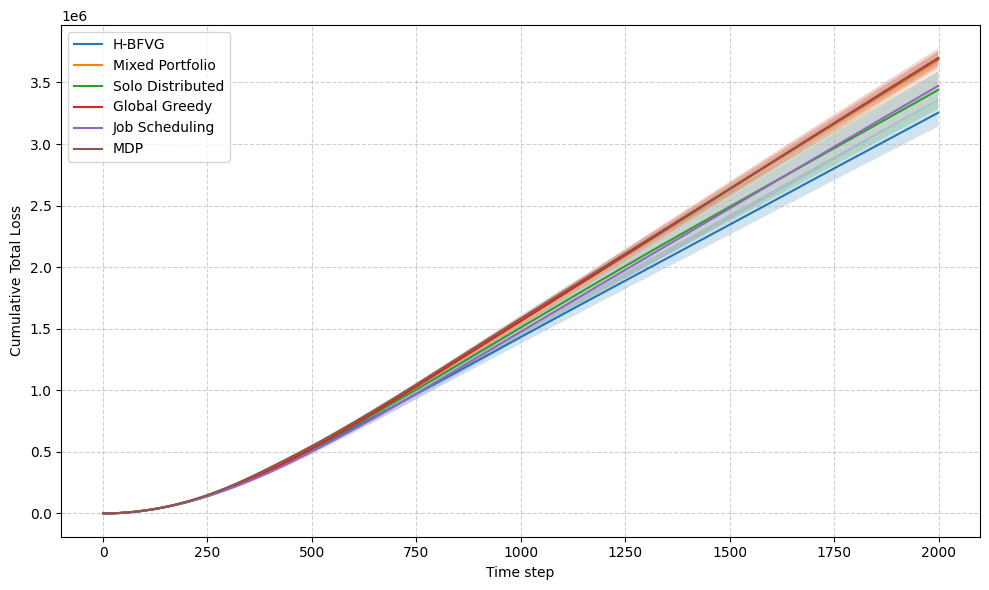

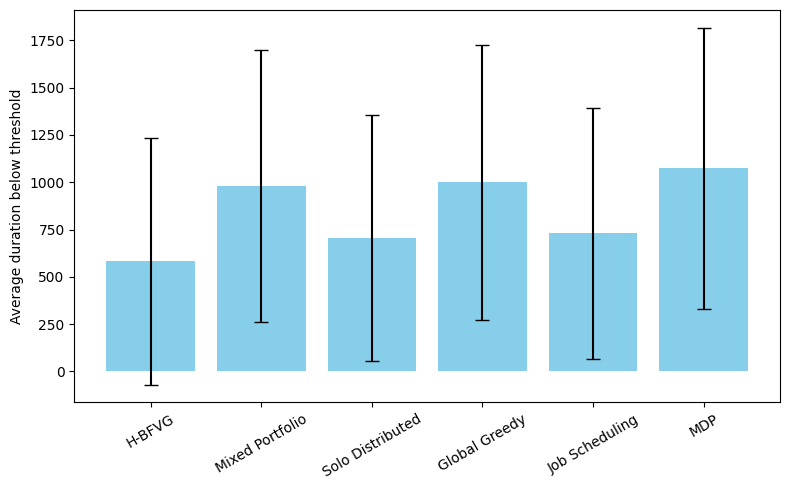

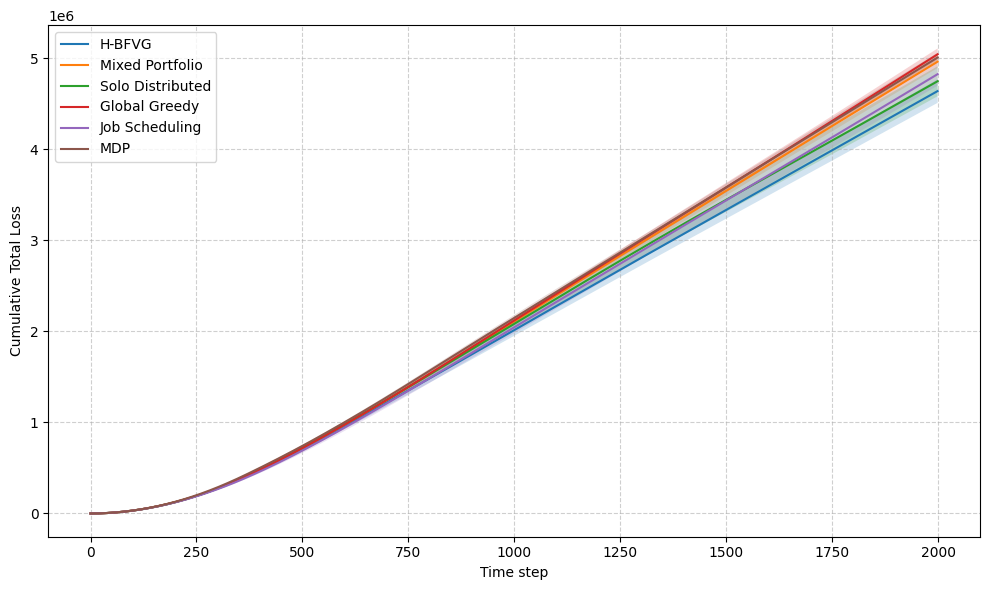

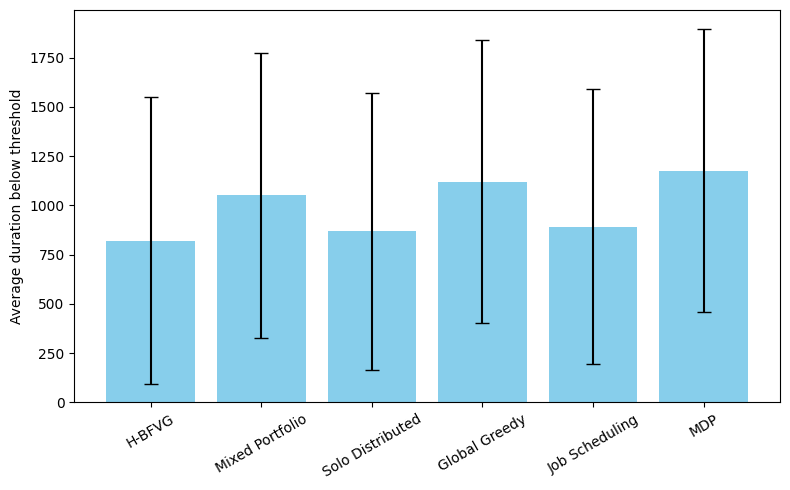

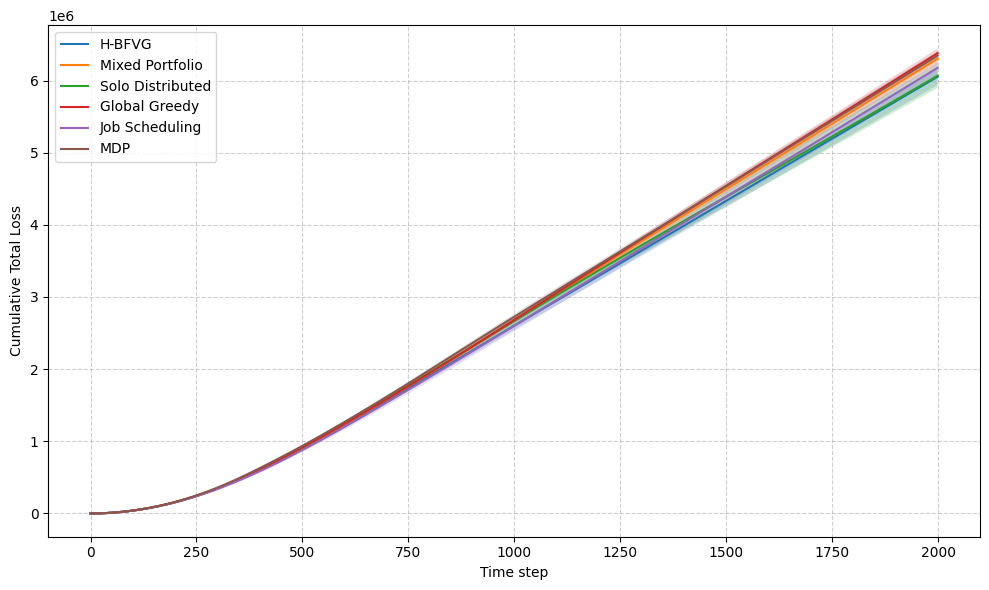

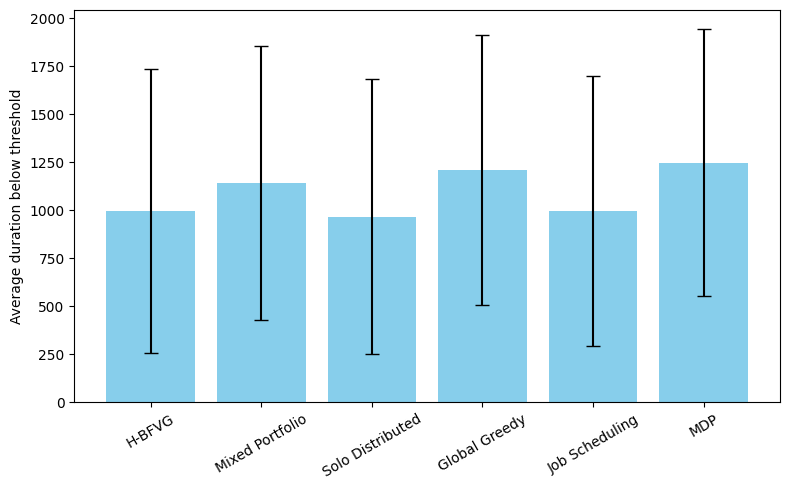

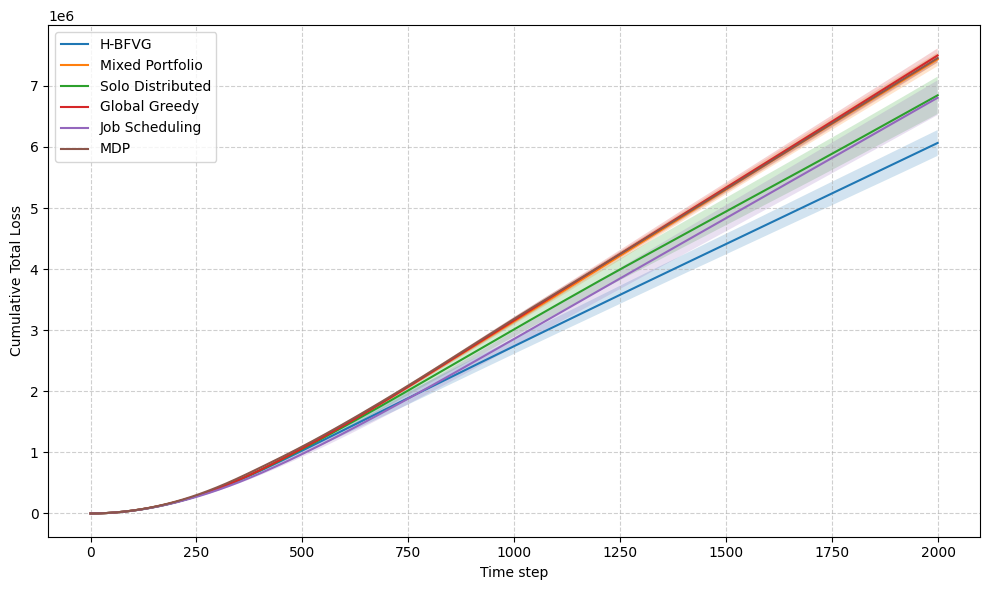

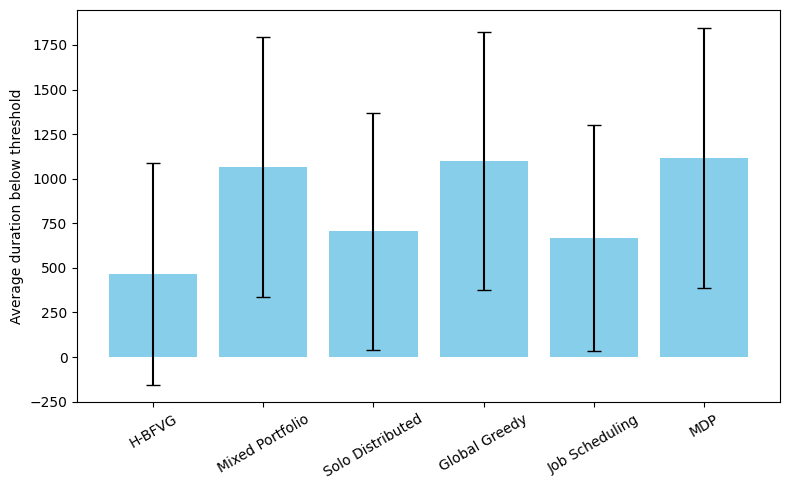

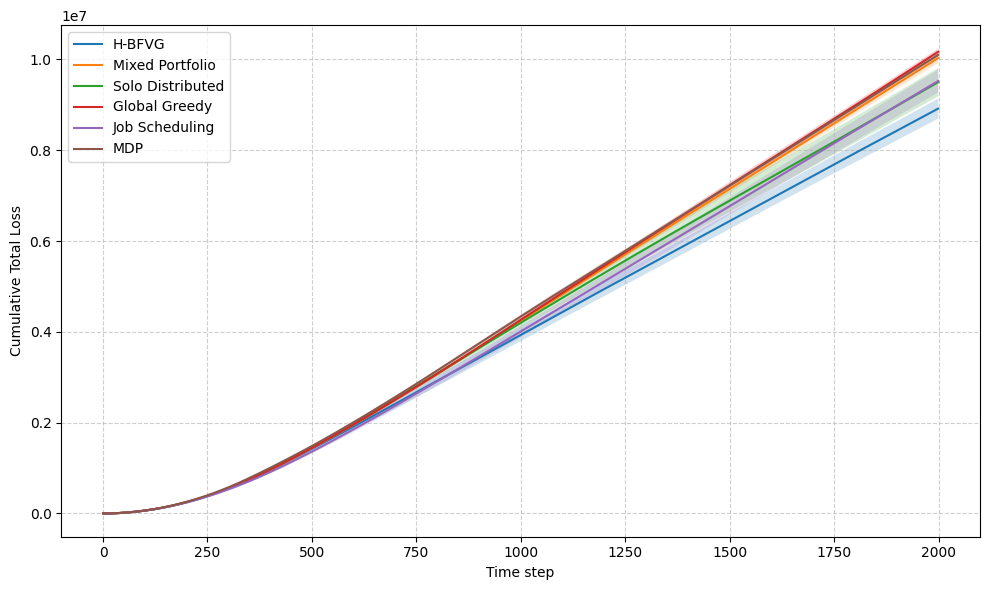

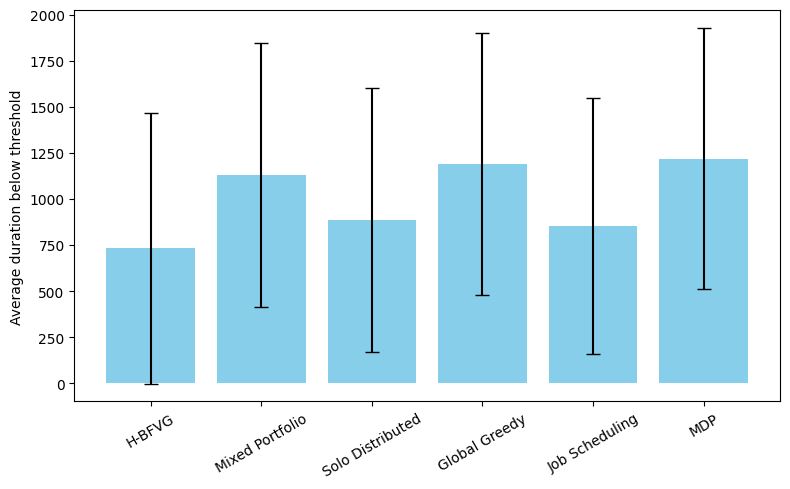

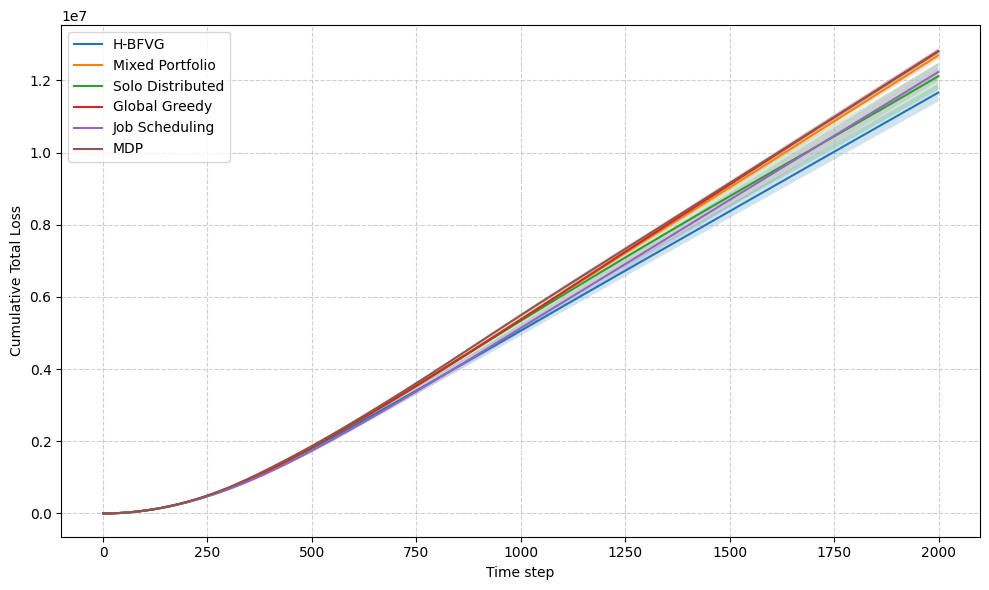

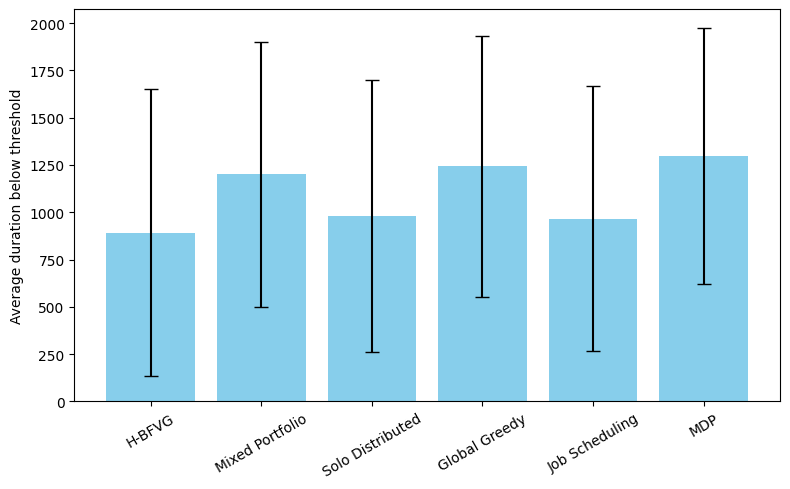

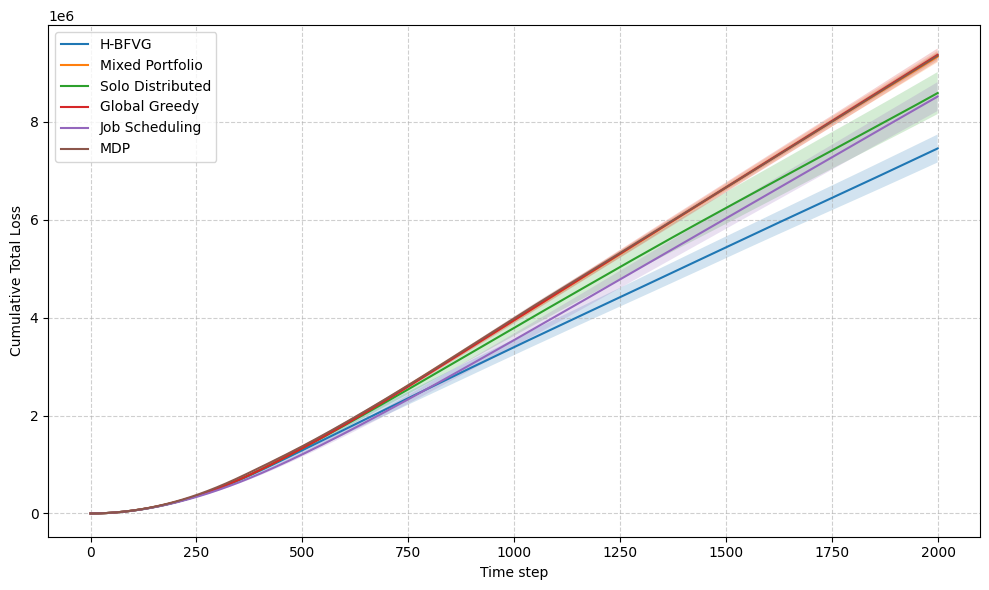

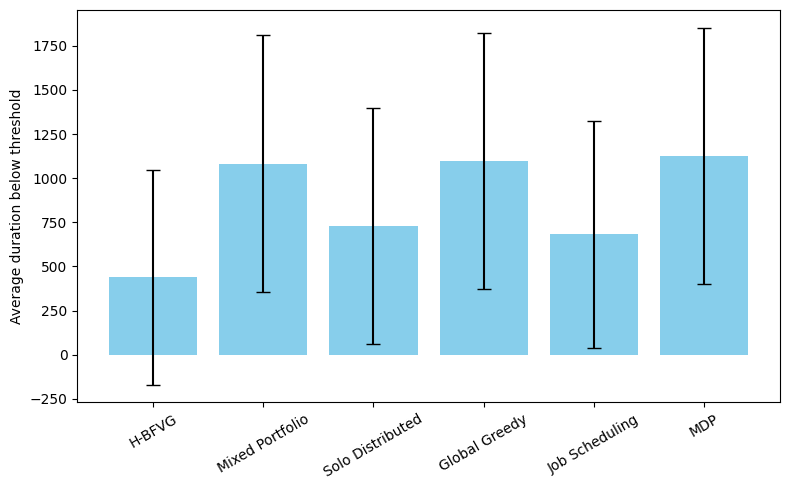

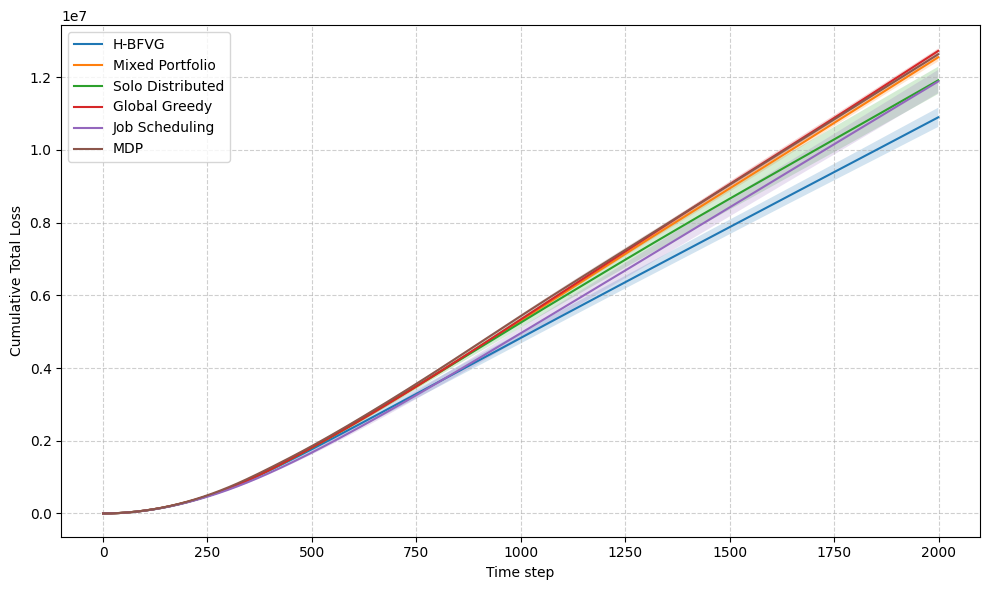

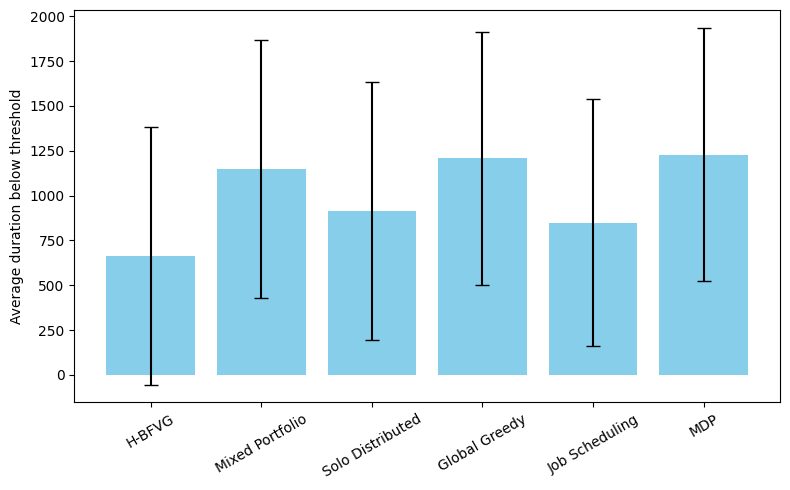

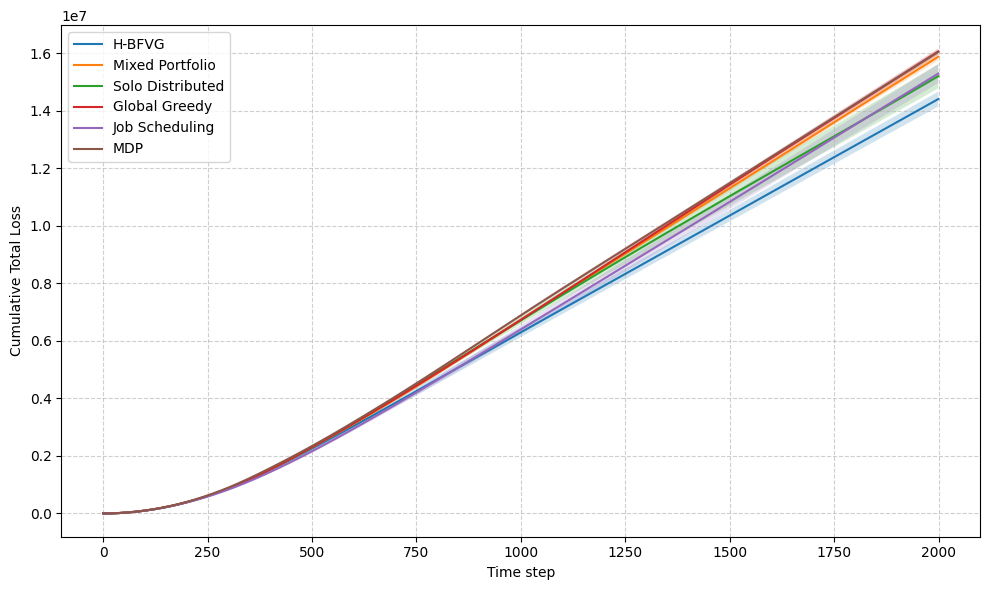

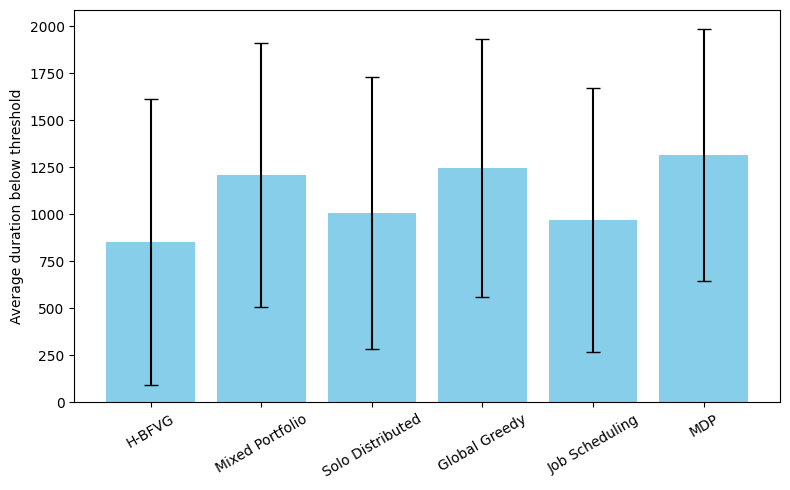

In [ ]:
ntrials = 100
T = 2000

input_nrobots, multiplier = (4, 8, 10), (6, 8, 10)
for nrobots in input_nrobots:
  for mult in multiplier:
    nareas = nrobots * mult
    all_losses = batch_experiments_collect_metrics(n_trials=ntrials, n_areas=nareas, n_robots=nrobots, env_size=(500, 500), T=T)
    plot_cumulative_loss_with_error(all_losses, T=T, filename='sim_quadrant_nrobots{}_nareas{}_cumulative_losses.pdf'.format(nrobots, nareas))
    plot_avg_duration_below_threshold(all_losses, filename='sim_quadrant_nrobots{}_nareas{}_ave_duration_threshold.pdf'.format(nrobots, nareas))

### Random config

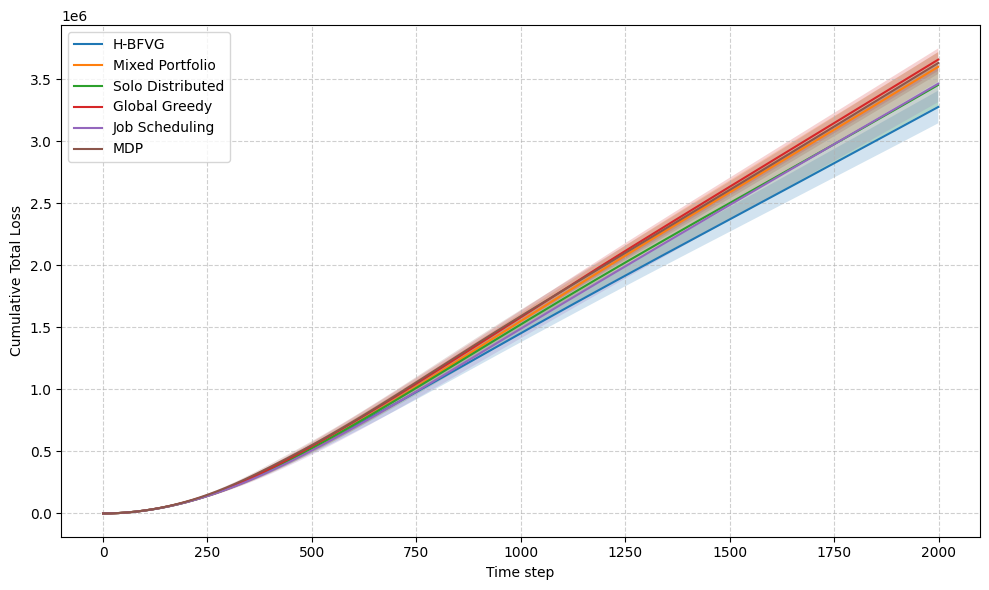

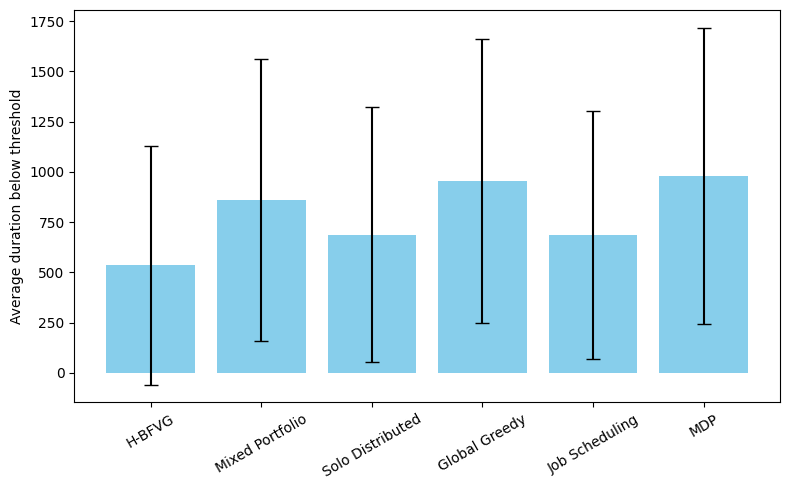

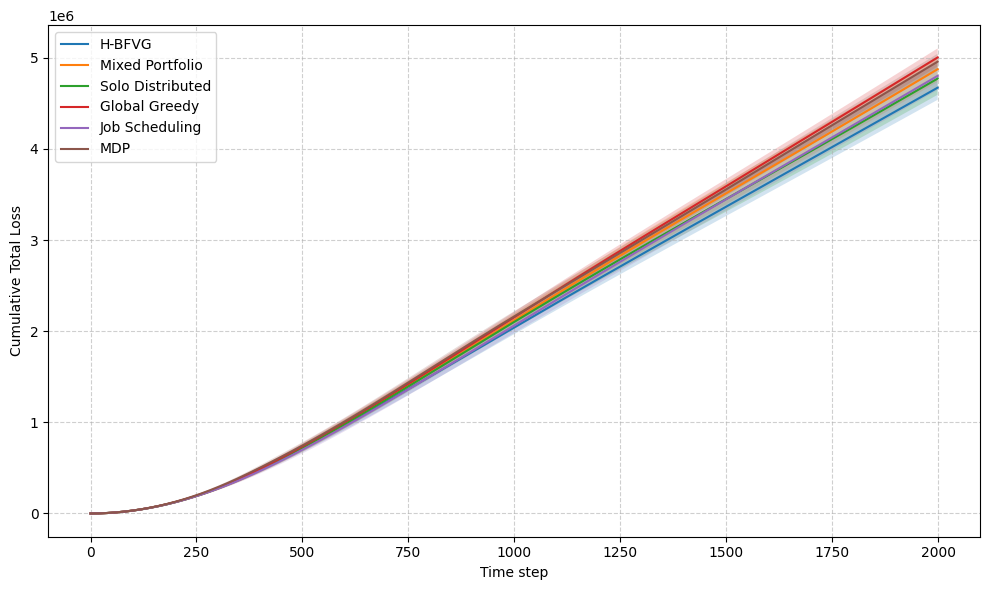

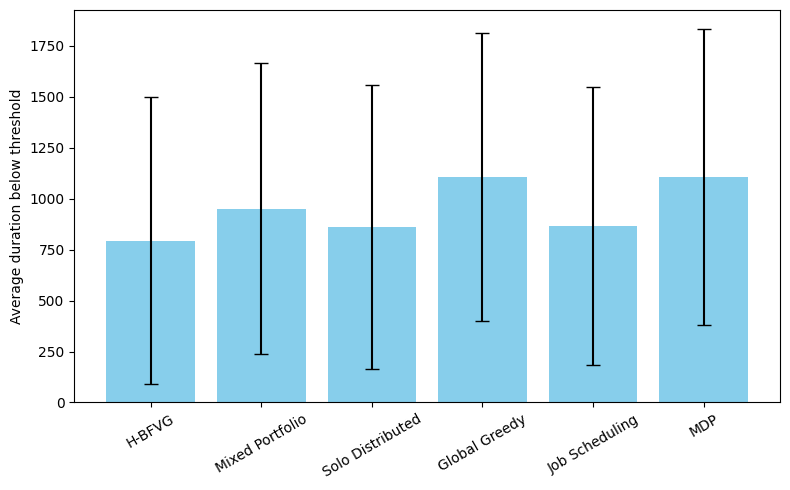

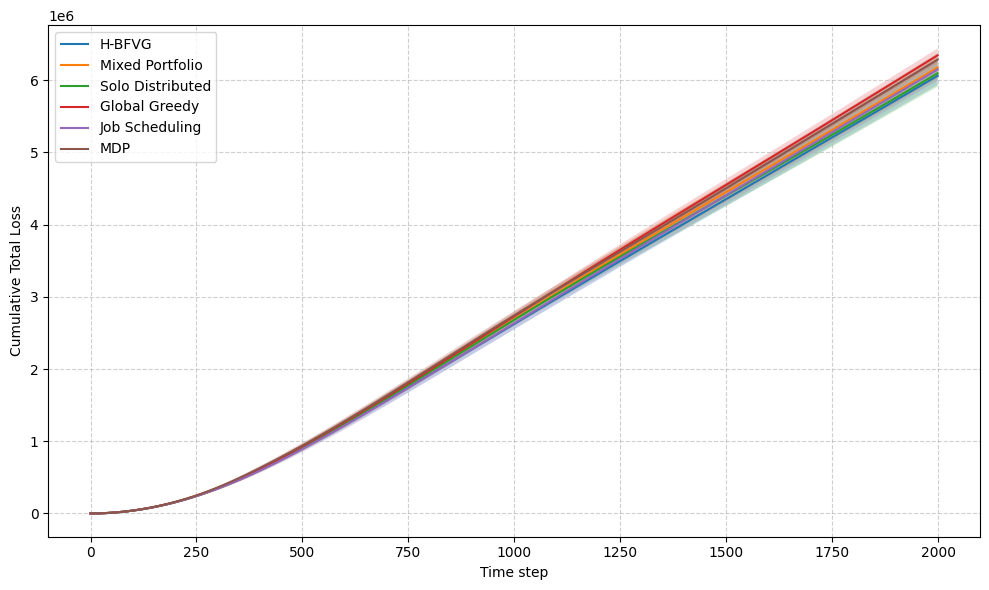

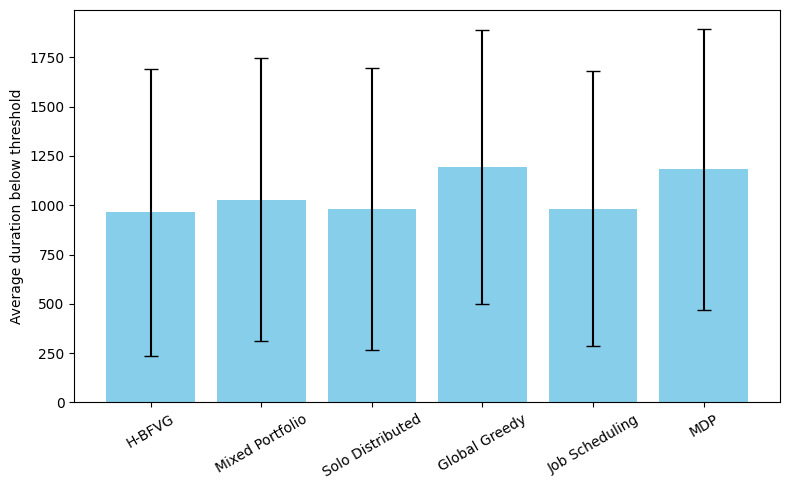

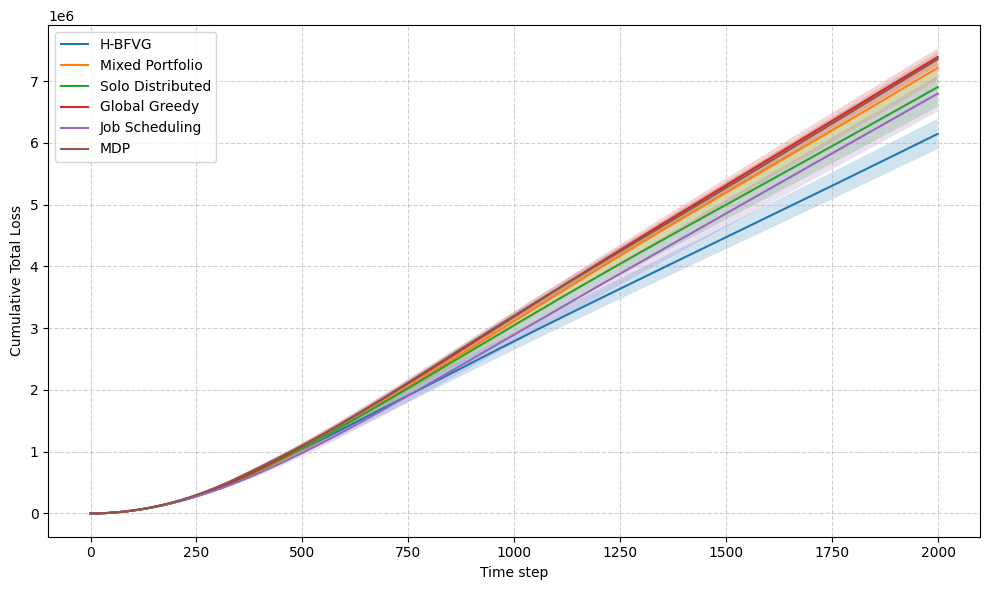

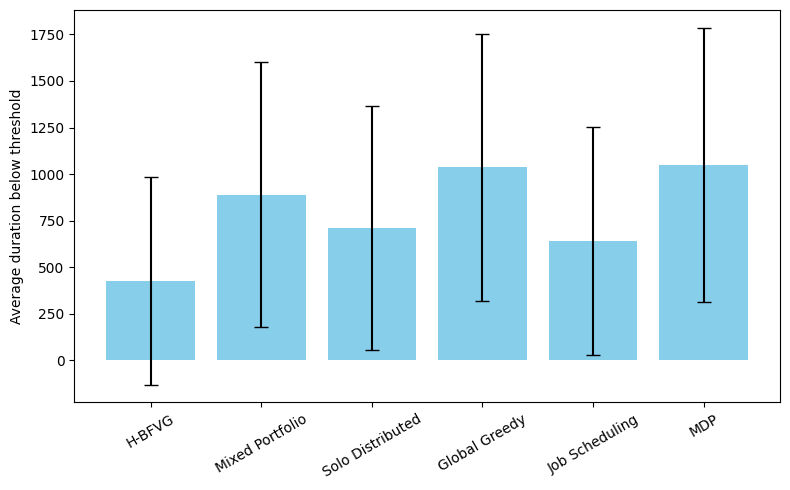

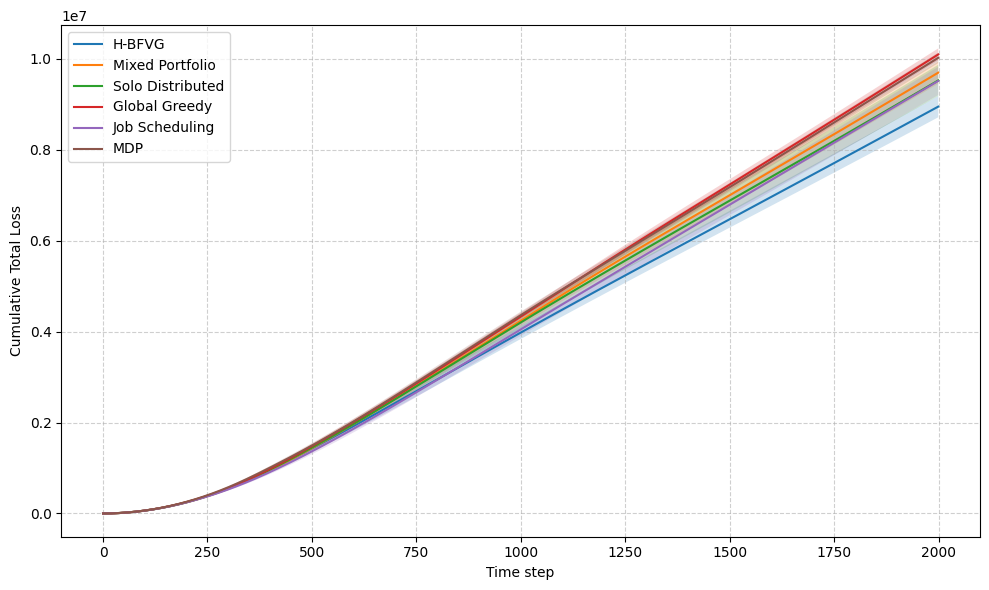

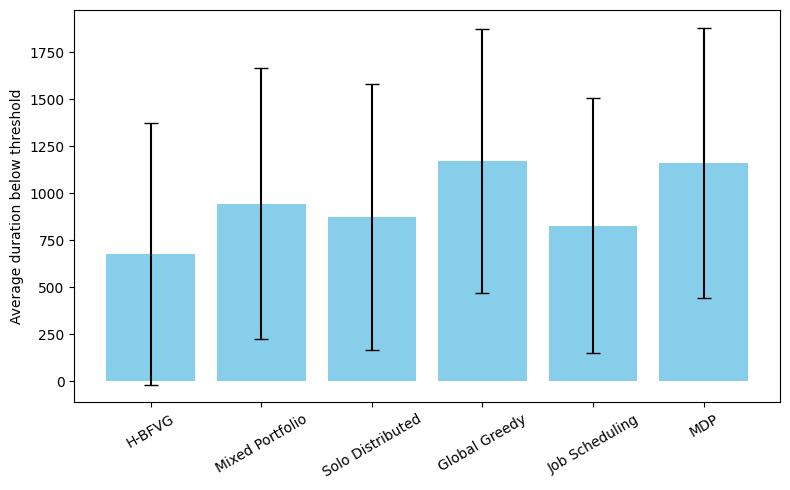

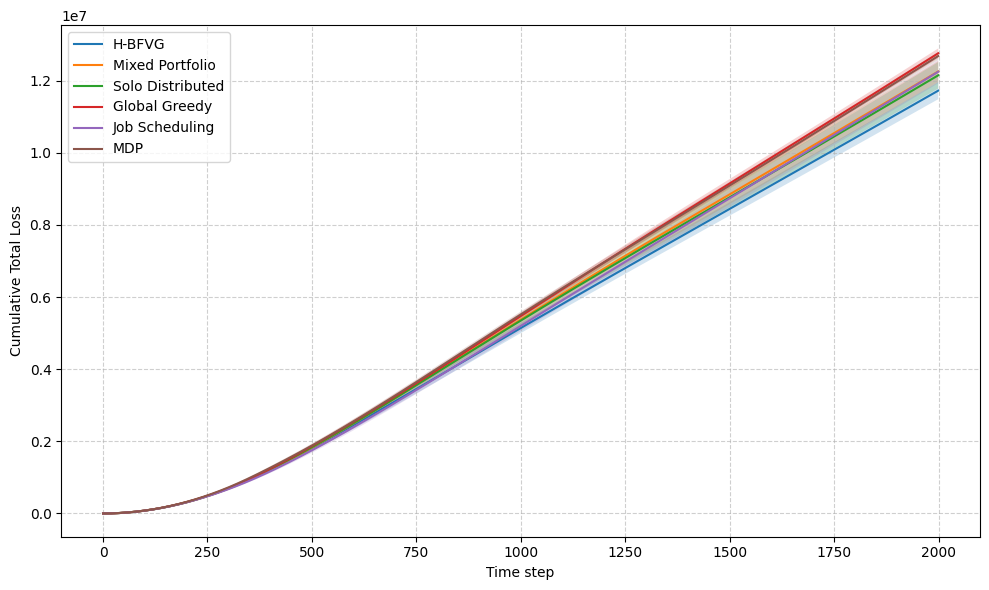

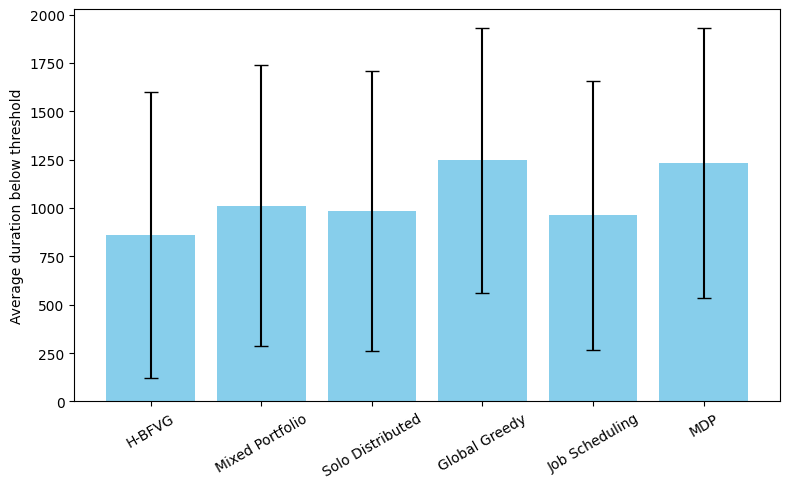

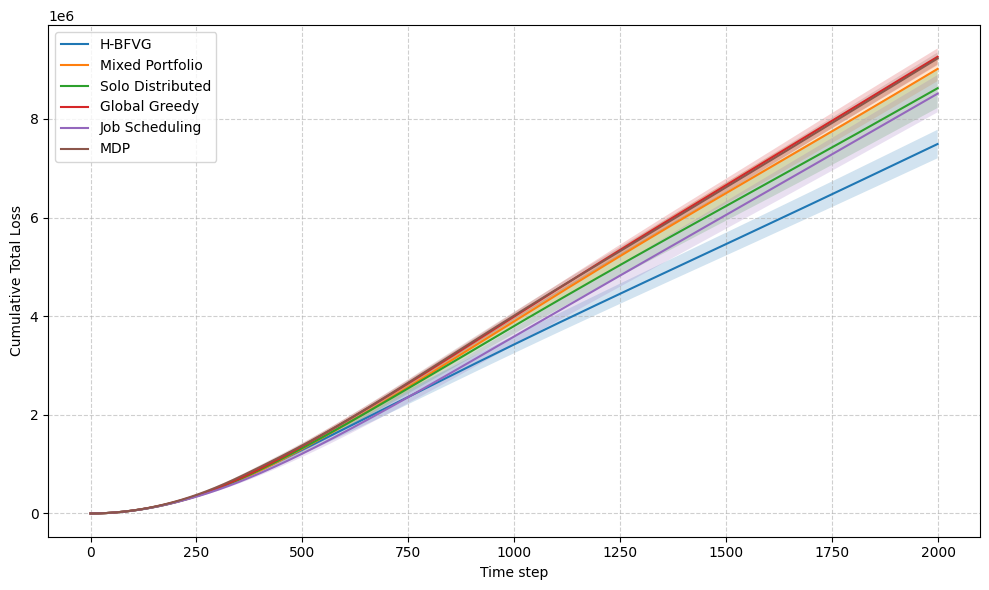

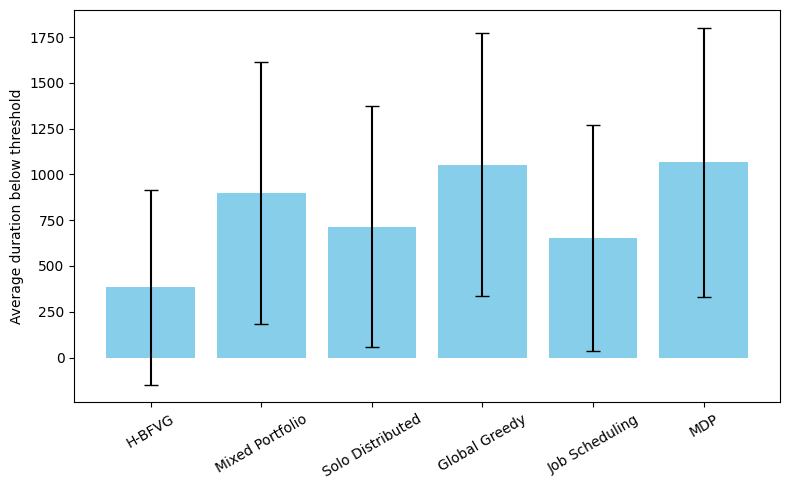

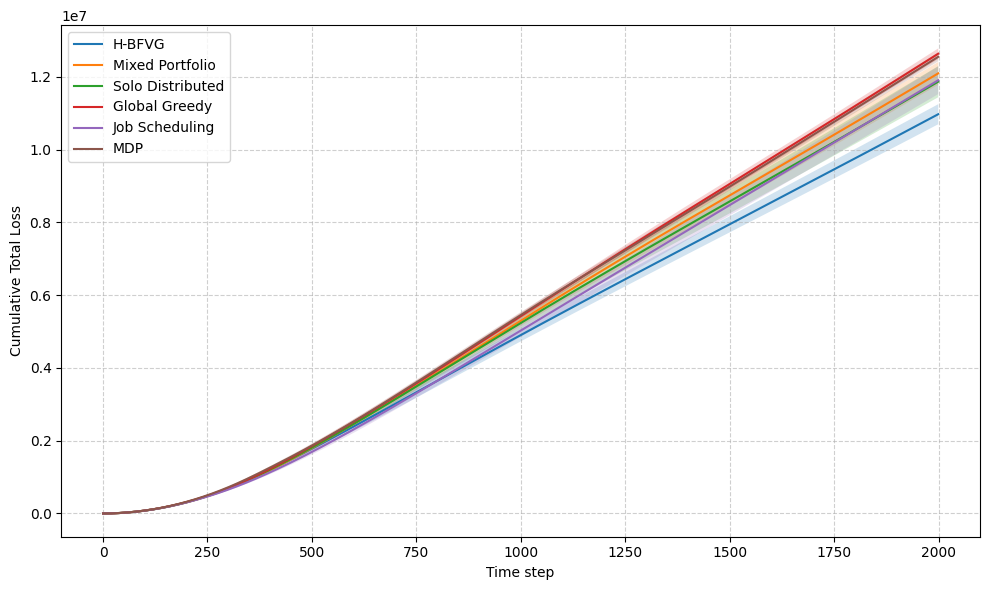

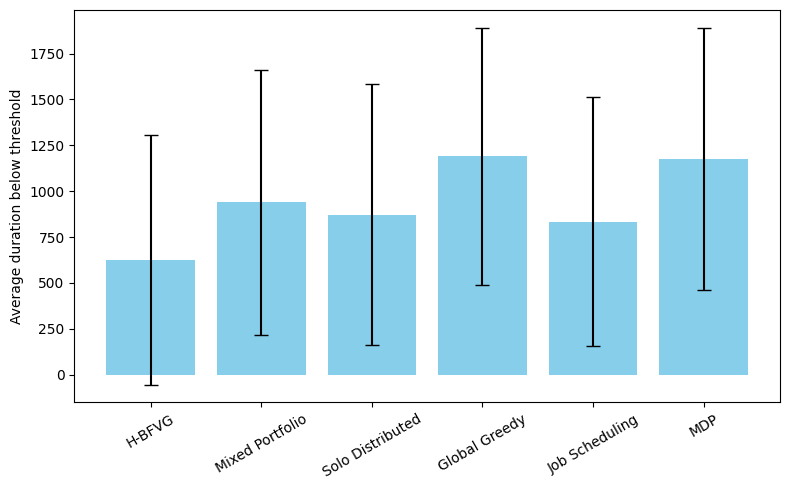

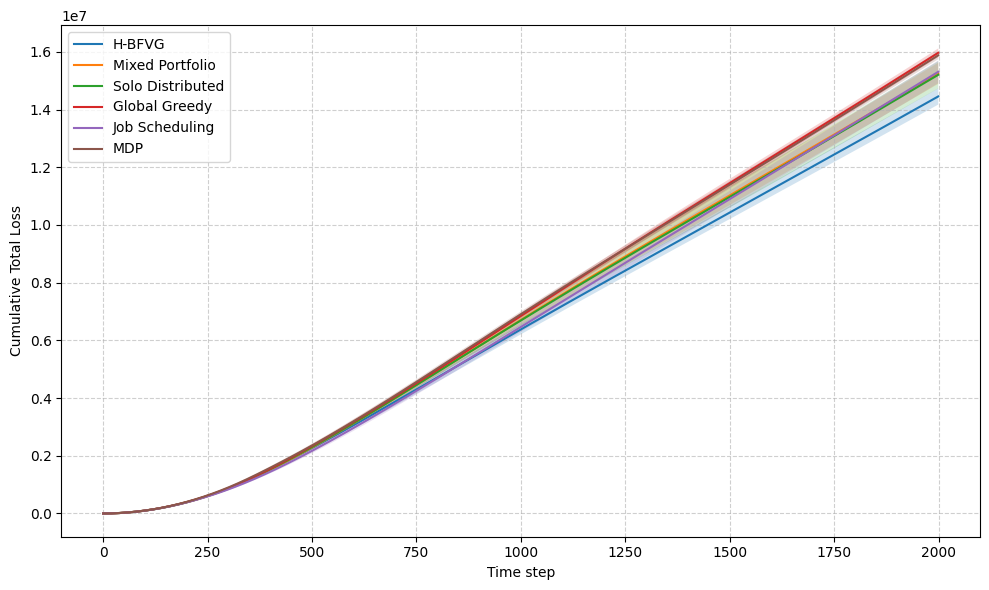

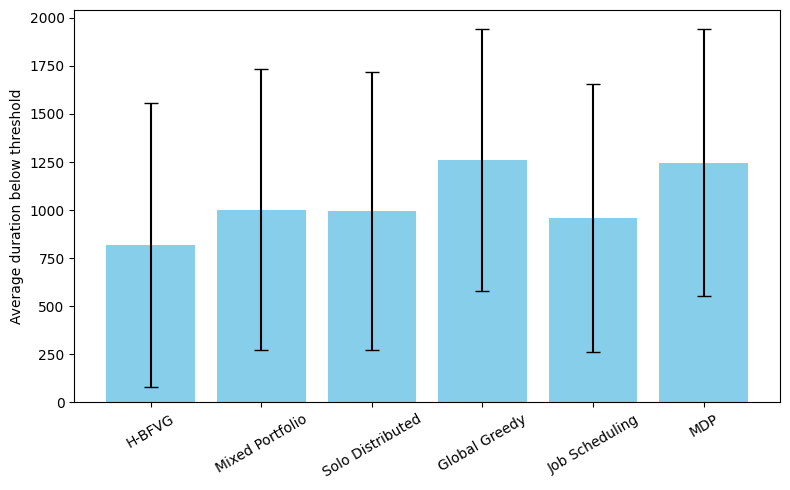

In [ ]:
ntrials = 1000
T = 2000

input_nrobots, multiplier = (4, 8, 10), (6, 8, 10)
for nrobots in input_nrobots:
  for mult in multiplier:
    nareas = nrobots * mult
    all_losses = batch_experiments_collect_metrics(n_trials=ntrials, n_areas=nareas, n_robots=nrobots, env_size=(500, 500), T=T, generate_inputs_func=generate_quadrant_star_inputs_random)
    plot_cumulative_loss_with_error(all_losses, T=T, filename='sim_random_nrobots{}_nareas{}_cumulative_losses.pdf'.format(nrobots, nareas))
    plot_avg_duration_below_threshold(all_losses, filename='sim_random_nrobots{}_nareas{}_ave_duration_threshold.pdf'.format(nrobots, nareas))

### Per-robot metrics

In [ ]:
def analyze_robot_efficiency(robots):
    """
    Returns a summary dictionary of per-robot efficiency:
    - total restored value
    - total distance traveled
    - restored per unit distance
    """
    robot_data = []
    for r in robots:
        efficiency = r.restored_value / r.distance_traveled if r.distance_traveled > 0 else 0
        robot_data.append({
            'robot_id': r.id,
            'restored_value': r.restored_value,
            'distance_traveled': r.distance_traveled,
            'restored_per_distance': efficiency,
        })
    return robot_data

In [ ]:
def analyze_area_preservation(areas, threshold=50.0):
    """
    For each area, computes:
    - % of time steps above threshold
    - total time below threshold
    """
    results = []
    for a in areas:
        below = sum(1 for f in a.history if f < threshold)
        total = len(a.history)
        preserved_pct = 100.0 * (total - below) / total if total > 0 else 0
        results.append({
            'area_id': a.id,
            'preserved_pct': preserved_pct,
            'time_below_threshold': below,
            'total_time_steps': total,
        })
    return results

In [ ]:
def summarize_robot_efficiency(robot_efficiency):
    total_restored = sum(d['restored_value'] for d in robot_efficiency)
    total_distance = sum(d['distance_traveled'] for d in robot_efficiency)
    avg_efficiency = total_restored / total_distance if total_distance > 0 else 0
    return {
        'total_restored': total_restored,
        'total_distance': total_distance,
        'avg_restored_per_distance': avg_efficiency,
    }

In [ ]:
def summarize_area_preservation(area_preservation):
    avg_preserved_pct = sum(a['preserved_pct'] for a in area_preservation) / len(area_preservation)
    return {
        'avg_preserved_pct': avg_preserved_pct,
        'num_areas': len(area_preservation)
    }

### Robot trajectories

In [ ]:
import matplotlib.patches as mpatches
from collections import defaultdict

In [ ]:
def plot_robot_trajectories(robots, areas, T_snapshot=None, decay_cmap='viridis', filename=None):
    """
    Plots robot trajectories as dashed arrows and area positions colored by decay rate.
    Only one legend entry per robot is shown.

    Args:
        robots: List of Robot objects.
        areas: List of Area objects.
        T_snapshot: Optional tuple (start_time, end_time).
        decay_cmap: Colormap name for area decay rates (default: 'viridis').
    """
    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    colors = plt.cm.tab10.colors

    # Normalize decay rates
    decay_rates = np.array([a.decay_rate for a in areas])
    norm = plt.Normalize(vmin=decay_rates.min(), vmax=decay_rates.max())
    cmap = plt.cm.get_cmap(decay_cmap)

    # Plot areas with decay-colored Xs
    for area in areas:
        x, y = area.position
        decay_color = cmap(norm(area.decay_rate))
        ax.scatter(x, y, color=decay_color, marker='x', s=80, zorder=3)
        ax.text(x + 1, y + 1, f"A{area.id}", fontsize=8)

    # Colorbar for decay rates
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Decay Rate')

    legend_handles = []

    # Plot robot trajectories
    for r in robots:
        traj = r.trajectory

        # Time filter
        if T_snapshot:
            t_start, t_end = T_snapshot
            traj = [(t, aid) for t, aid in traj if t_start <= t <= t_end]

        positions = []
        for t, area_id in traj:
            area = next((a for a in areas if a.id == area_id), None)
            if area:
                positions.append(area.position)

        if len(positions) > 1:
            color = colors[r.id % len(colors)]
            for i in range(len(positions) - 1):
                start = positions[i]
                end = positions[i + 1]
                dx, dy = end - start
                ax.arrow(start[0], start[1], dx, dy,
                         head_width=1.5, head_length=2.0,
                         fc=color, ec=color,
                         linestyle='dashed',
                         alpha=0.5,
                         length_includes_head=True,
                         zorder=2)
            # Add one legend handle for this robot
            legend_handles.append(
                mpatches.Patch(color=color, label=f"Robot {r.id}", alpha=0.5)
            )

    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    # ax.set_title(f"Robot Trajectories" + (f" (t ∈ [{T_snapshot[0]}, {T_snapshot[1]}])" if T_snapshot else ""))
    ax.legend(handles=legend_handles)
    ax.grid(True)
    ax.axis("equal")
    plt.tight_layout()
    # Save the plot if a filename is provided
    if filename:
        plt.savefig(filename, bbox_inches='tight')
    plt.show()

#### Interactive widget

In [ ]:
from ipywidgets import interact, IntSlider, fixed
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.lines import Line2D

In [ ]:
def plot_robot_trajectories_at_time(robots, areas, t):
    """
    Plot robot trajectories up to time t with arrow heads and decay rate colorbar.
    """
    fig, ax = plt.subplots(figsize=(10, 8))

    # Color mapping for decay rates
    decay_rates = [a.decay_rate for a in areas]
    norm = colors.Normalize(vmin=min(decay_rates), vmax=max(decay_rates))
    cmap = cm.viridis

    # Plot areas with decay-based color
    for area in areas:
        x, y = area.position
        ax.scatter(x, y, color=cmap(norm(area.decay_rate)), marker='x', s=80)
        ax.text(x + 1, y + 1, f"A{area.id}", fontsize=8)

    # Plot robot trajectories with fading effect
    proxy_lines = []

    for r in robots:
        traj = [(time, area_id) for time, area_id in r.trajectory if time <= t]
        if traj:
            positions = [a.position for _, aid in traj for a in areas if a.id == aid]
            positions = np.array(positions)

            if len(positions) > 1:
                for i in range(len(positions) - 1):
                    alpha = 0.2 + 0.8 * ((i + 1) / len(positions))
                    ax.arrow(
                        positions[i][0], positions[i][1],
                        positions[i+1][0] - positions[i][0],
                        positions[i+1][1] - positions[i][1],
                        head_width=0.8, head_length=1.2, fc='C'+str(r.id), ec='C'+str(r.id),
                        linestyle='--', alpha=alpha, length_includes_head=True
                    )
                # Add proxy for legend
                proxy_lines.append(Line2D([0], [0], color='C'+str(r.id), linestyle='--', label=f"Robot {r.id}"))

    # Legend and colorbar
    ax.legend(handles=proxy_lines, title="Robots")
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Decay Rate")

    # Aesthetic tweaks
    ax.set_title(f"Robot Trajectories Up to Time {t}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True)
    ax.axis("equal")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

In [ ]:
def interactive_robot_trajectories(robots, areas, T):
    """Interactive time slider for trajectories."""
    interact(
        plot_robot_trajectories_at_time,
        robots=fixed(robots),
        areas=fixed(areas),
        t=IntSlider(min=0, max=T, step=10, value=0)
    )

In [ ]:
def compare_star_methods_plot(n_areas=12, n_robots=3, T=500, seed=42, env_size=(100, 100), decay_range=None, arrangement='quadrant', snapshot=None):
    methods = {}

    if arrangement == 'quadrant':
      original_areas, original_robots = generate_quadrant_star_inputs(
          n_areas=n_areas,
          n_robots=n_robots,
          env_size=env_size,
          min_dist=5,
          decay_range=decay_range,
          seed=seed
      )
    else:
      original_areas, original_robots = generate_quadrant_star_inputs_random(
          n_areas=n_areas,
          n_robots=n_robots,
          env_size=env_size,
          min_dist=5,
          decay_range=decay_range,
          seed=seed
      )

    # Clustering
    print("H-BFVG")
    areas = copy.deepcopy(original_areas)
    robots = copy.deepcopy(original_robots)
    assignments = fixed_cluster_assignment(areas, robots, n_robots)
    areas_fc, robots_fc = simulate_star(assignments, areas, robots, T=T)
    methods['H-BFVG'] = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_fc))

    # Mixed Portfolio
    print("Mixed Portfolio")
    areas = copy.deepcopy(original_areas)
    robots = copy.deepcopy(original_robots)
    assignments = mixed_portfolio_assignment(areas, robots, n_robots)
    areas_mp, robots_mp = simulate_star(assignments, areas, robots, T=T)
    methods['Mixed Portfolio'] = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_mp))

    # Repeated Solo Split
    print("Repeated Solo Split")
    areas = copy.deepcopy(original_areas)
    robots = copy.deepcopy(original_robots)
    assignments = repeated_solo_split_assignment(areas, robots, n_robots, method="greedy")
    areas_rs, robots_rs = simulate_star(assignments, areas, robots, T=T)
    methods['Solo Distributed'] = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_rs))

    # Global Greedy (Dynamic)
    print("Global Greedy")
    areas = copy.deepcopy(original_areas)
    robots = copy.deepcopy(original_robots)
    dynamic_fn = global_greedy_callback_builder(k=n_robots)
    areas_gg, robots_gg = simulate_star(dynamic_assignment_fn=dynamic_fn, areas=areas, robots=robots, T=T)
    methods['Global Greedy'] = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_gg))

    # MDP
    print("MDP")
    areas = copy.deepcopy(original_areas)
    robots = copy.deepcopy(original_robots)
    dyn_fn = mdp_k_step_rollout_callback_builder(k=3, velocity=1.0, alpha_move=0.0, gamma=0.98, per_robot_top=2)
    areas_ro, robots_ro = simulate_star(dynamic_assignment_fn=dyn_fn,
                                        areas=areas,
                                        robots=robots,
                                        T=T, F_max=100.0, velocity=1.0)

    cum_loss_ro = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_ro))
    methods['MDP'] = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_ro))


    # Job Scheduling (Dynamic)
    print("Job Scheduling")
    areas = copy.deepcopy(original_areas)
    robots = copy.deepcopy(original_robots)
    dynamic_fn = job_scheduler_callback_builder()
    areas_js, robots_js = simulate_star(dynamic_assignment_fn=dynamic_fn, areas=areas, robots=robots, T=T)
    methods['Job Scheduling'] = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_js))

    # Plot results
    plt.figure(figsize=(10,6))
    for label, cumulative_loss in methods.items():
        plt.plot(cumulative_loss, label=label)
    plt.xlabel("Time Step")
    plt.ylabel("Cumulative Total Loss")
    plt.title("Comparison of STAR Multi-Robot Methods")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot trajectories
    if snapshot is None:
      snapshot = (T/2, T)
    plot_robot_trajectories(robots_fc, areas_fc, T_snapshot=snapshot, filename='sim_{}_nrobots{}_nareas{}_sample_clustering.pdf'.format(arrangement, n_robots, n_areas))
    plot_robot_trajectories(robots_mp, areas_mp, T_snapshot=snapshot, filename='sim_{}_nrobots{}_nareas{}_sample_mixed_portfolio.pdf'.format(arrangement, n_robots, n_areas))
    plot_robot_trajectories(robots_gg, areas_gg, T_snapshot=snapshot, filename='sim_{}_nrobots{}_nareas{}_sample_global_greedy.pdf'.format(arrangement, n_robots, n_areas))
    plot_robot_trajectories(robots_ro, areas_ro, T_snapshot=snapshot, filename='sim_{}_nrobots{}_nareas{}_sample_mdp.pdf'.format(arrangement, n_robots, n_areas))
    plot_robot_trajectories(robots_js, areas_js, T_snapshot=snapshot, filename='sim_{}_nrobots{}_nareas{}_sample_job_sched.pdf'.format(arrangement, n_robots, n_areas))
    plot_robot_trajectories(robots_rs, areas_rs, T_snapshot=snapshot, filename='sim_{}_nrobots{}_nareas{}_sample_repeated_solo.pdf'.format(arrangement, n_robots, n_areas))


H-BFVG
Mixed Portfolio
Repeated Solo Split
Global Greedy
MDP
Job Scheduling


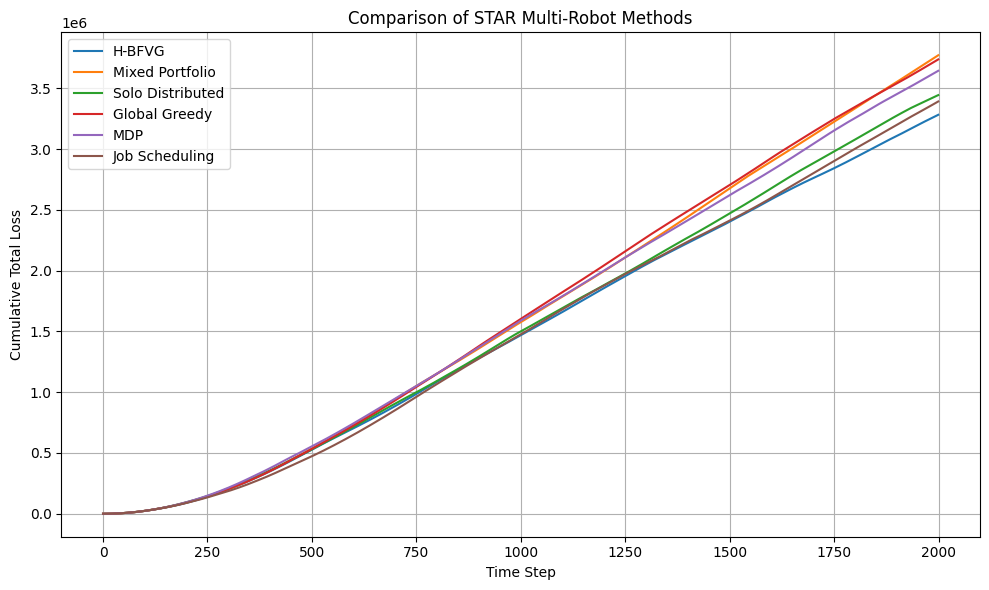

/tmp/ipython-input-671340735.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(decay_cmap)


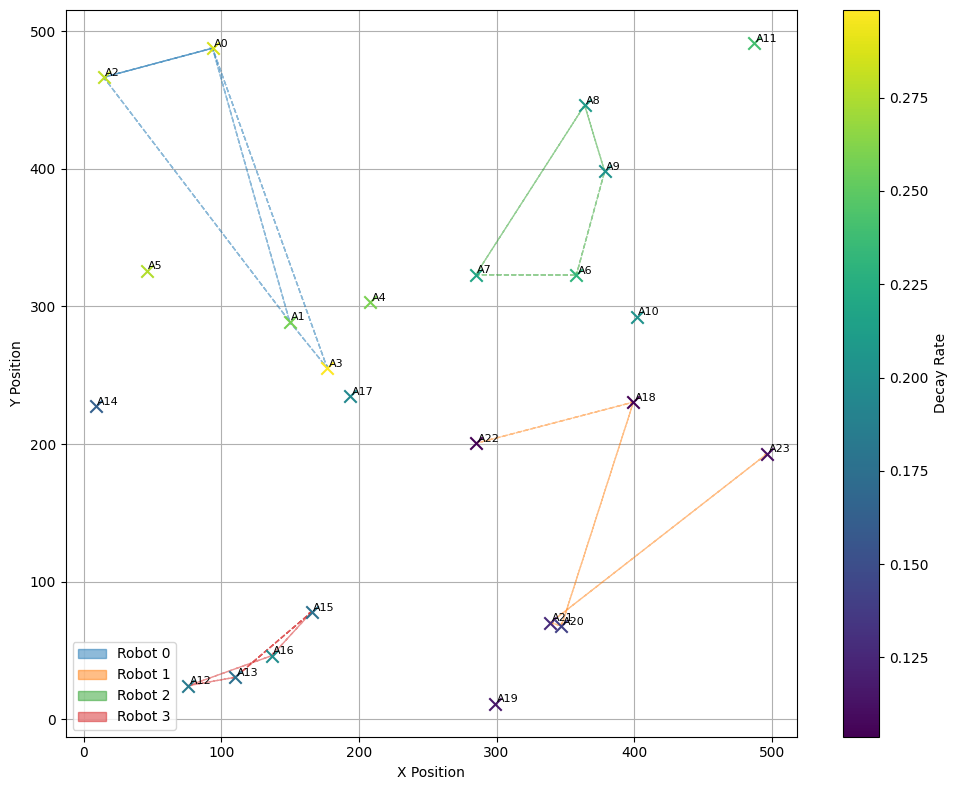

/tmp/ipython-input-671340735.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(decay_cmap)


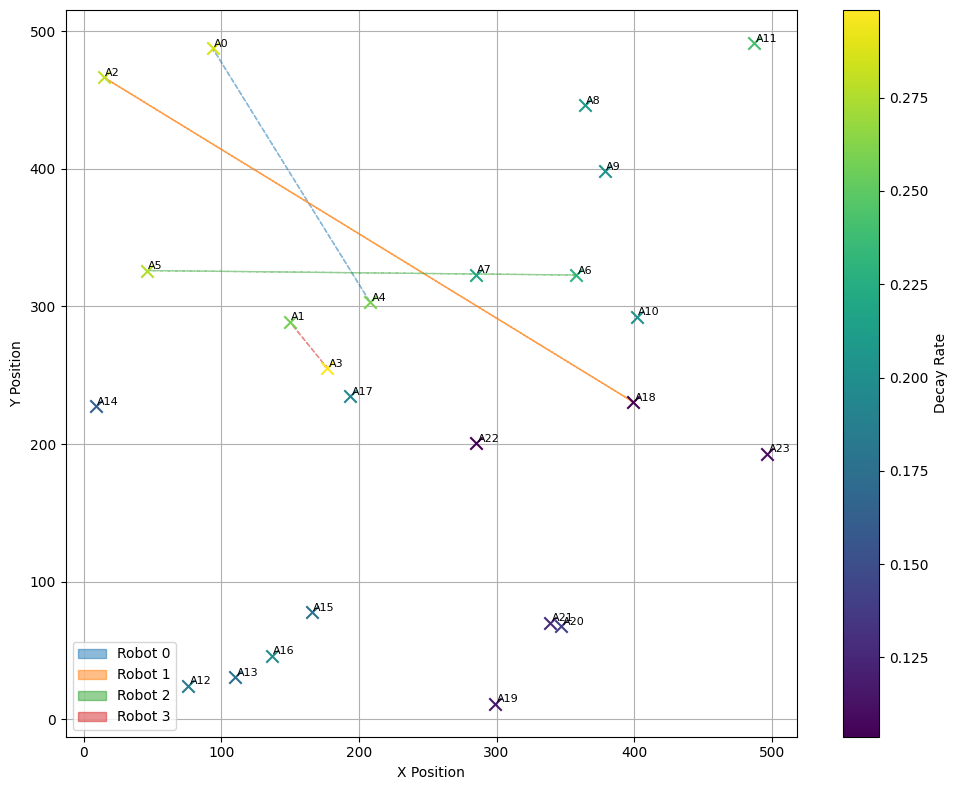

/tmp/ipython-input-671340735.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(decay_cmap)


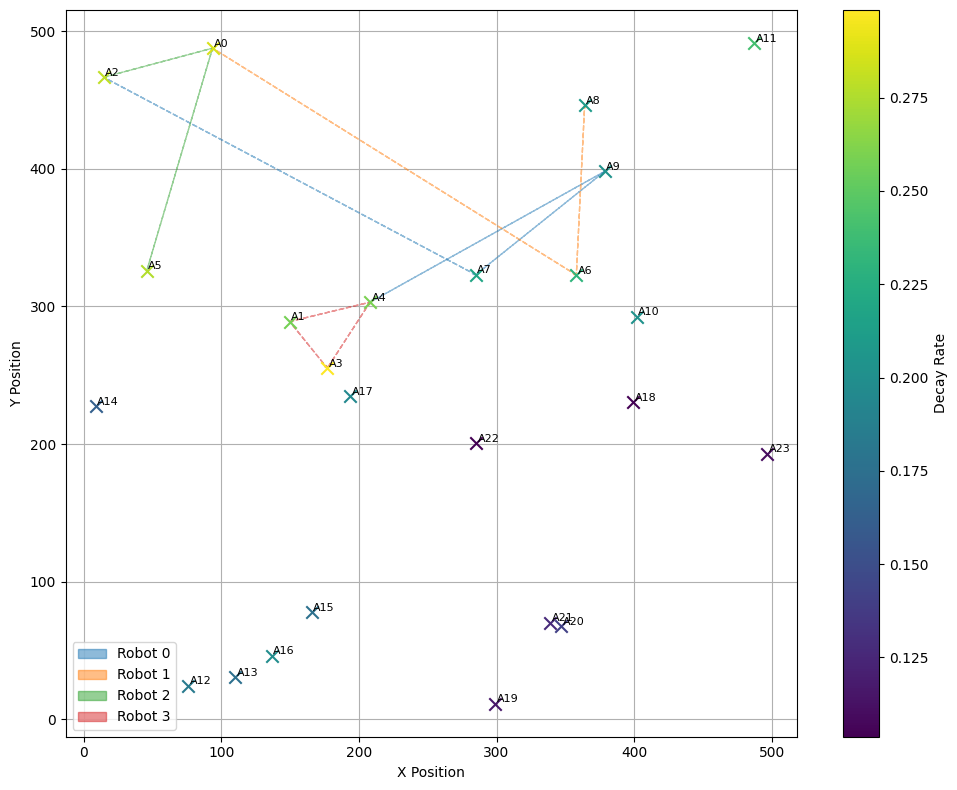

/tmp/ipython-input-671340735.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(decay_cmap)


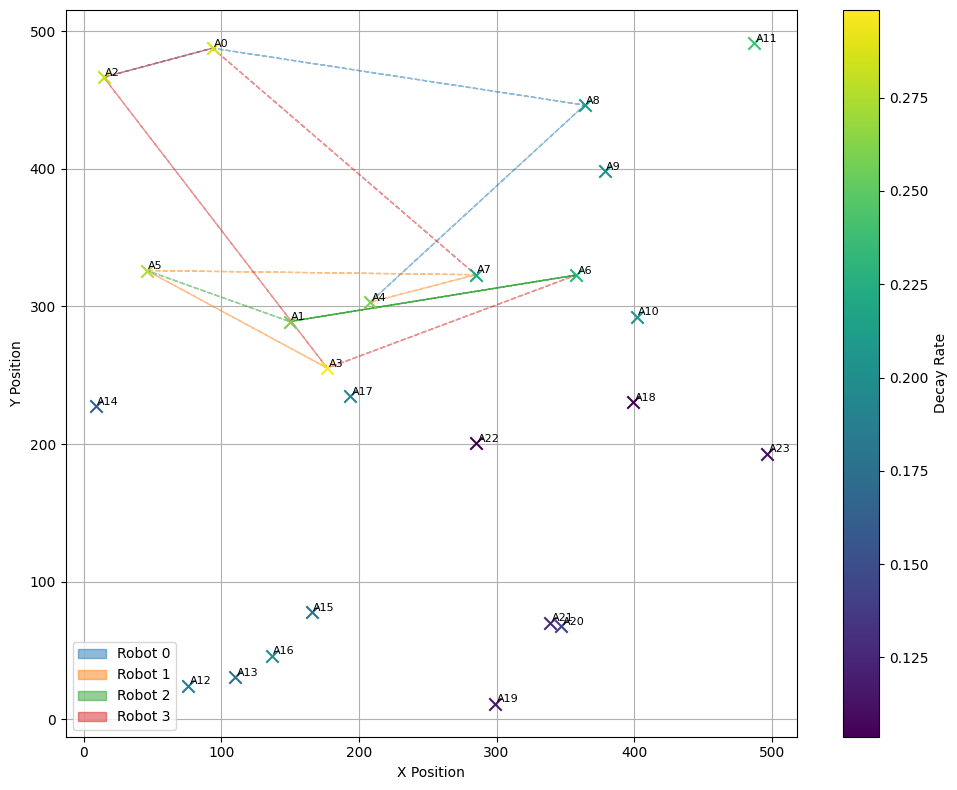

/tmp/ipython-input-671340735.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(decay_cmap)


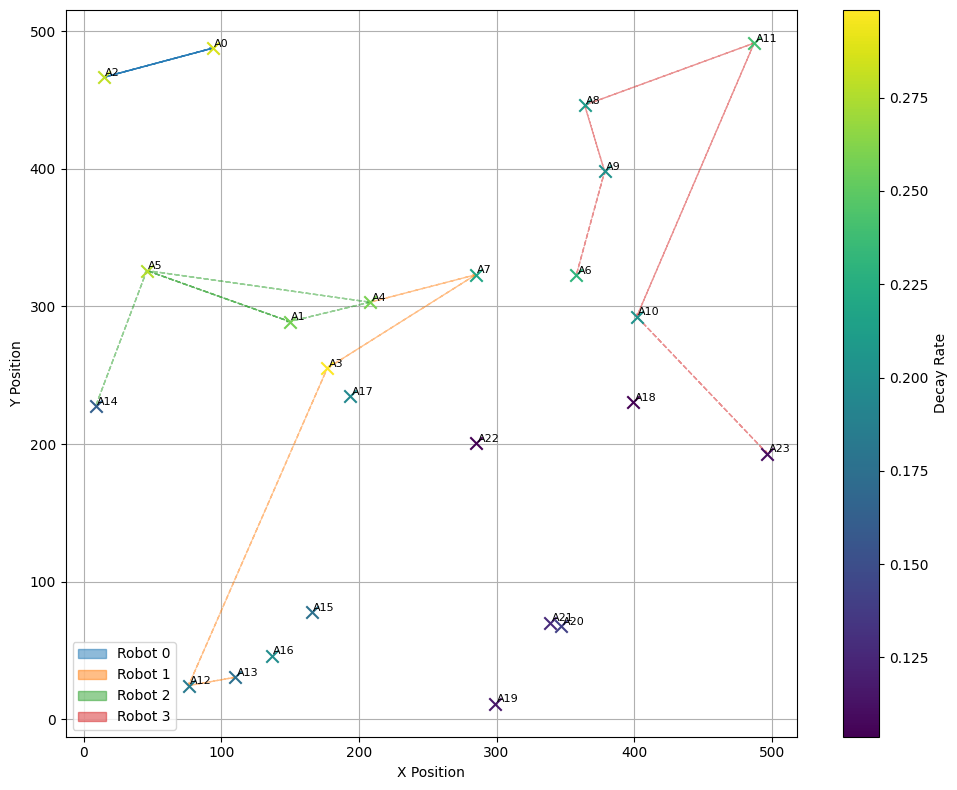

/tmp/ipython-input-671340735.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(decay_cmap)


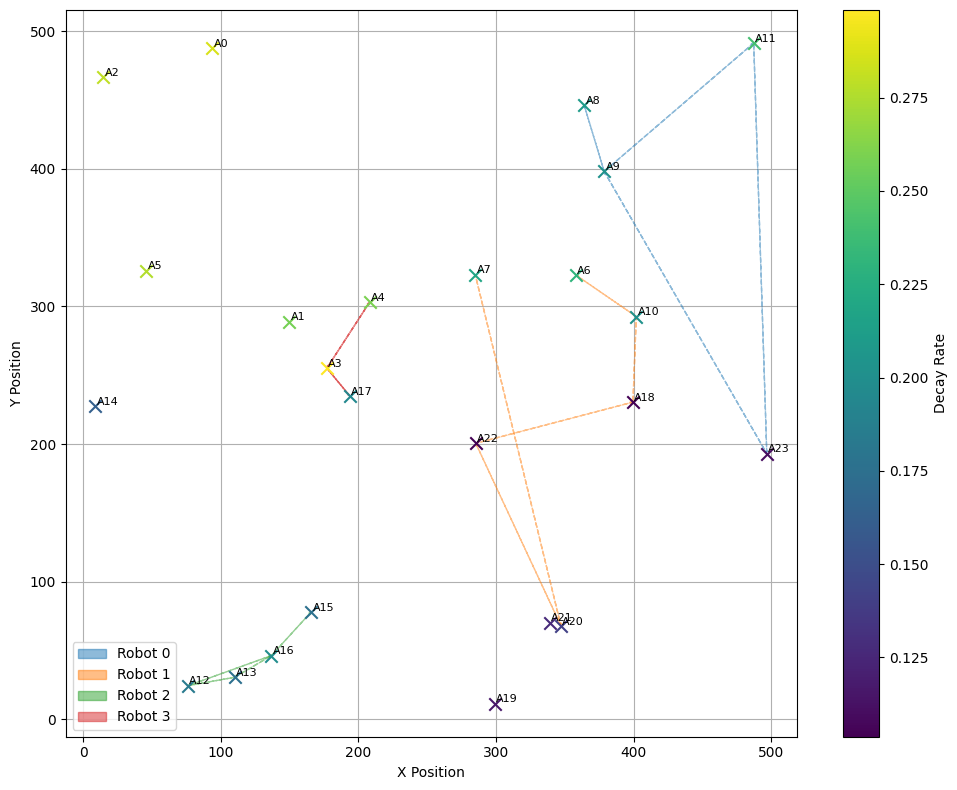

In [ ]:
#Sample one result from quadrant arrangement. Plot their trajectories
compare_star_methods_plot(n_areas=24, n_robots=4, T=2000, seed=42, env_size=(500, 500), decay_range=(0.10, 0.30), arrangement='quadrant')

H-BFVG
Mixed Portfolio
Repeated Solo Split
Global Greedy
MDP
Job Scheduling


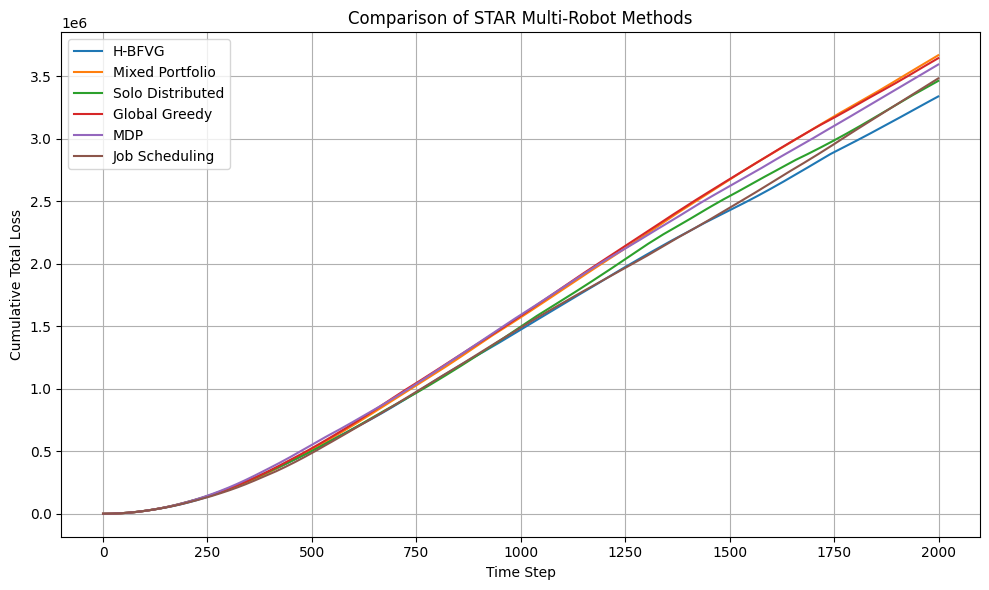

/tmp/ipython-input-671340735.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(decay_cmap)


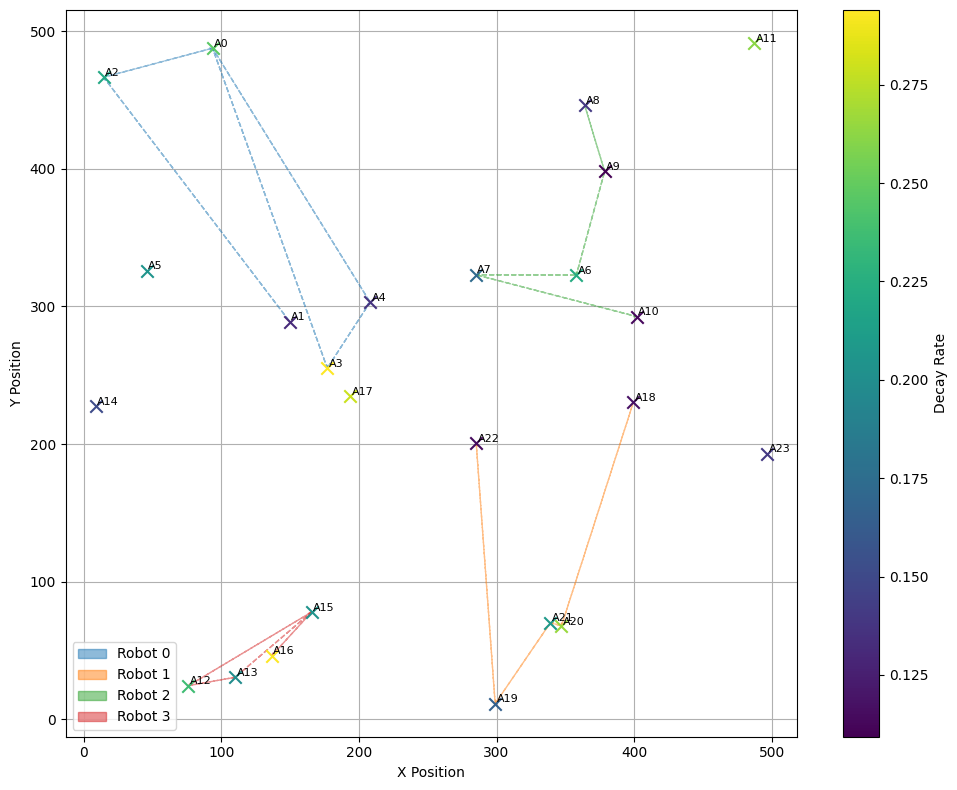

/tmp/ipython-input-671340735.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(decay_cmap)


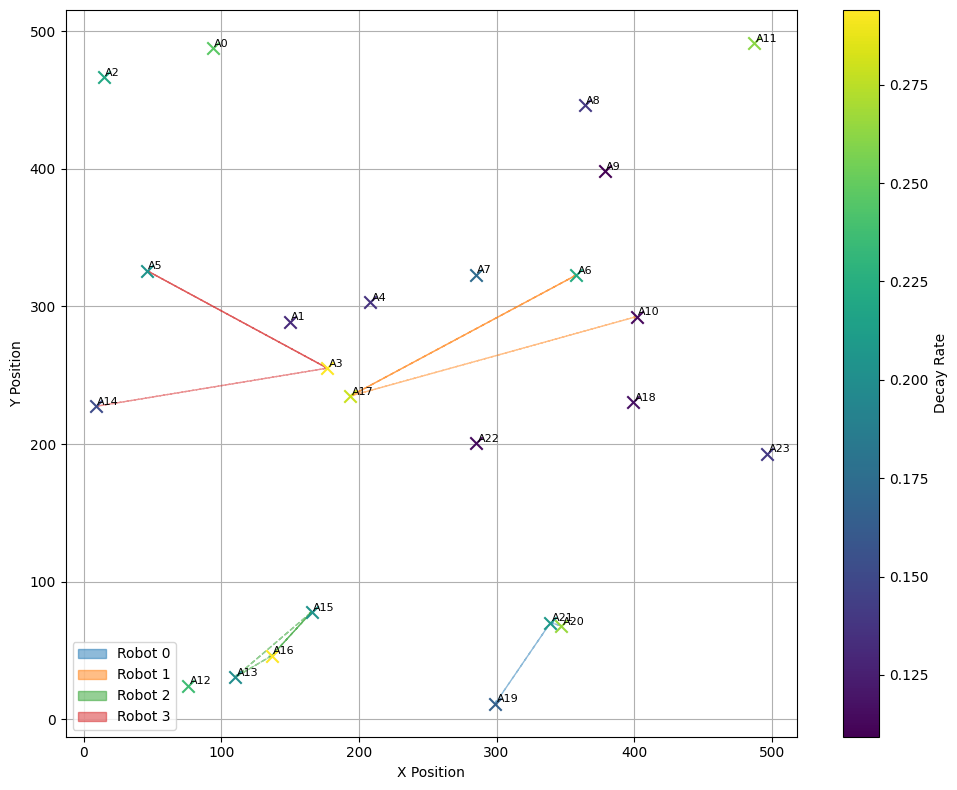

/tmp/ipython-input-671340735.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(decay_cmap)


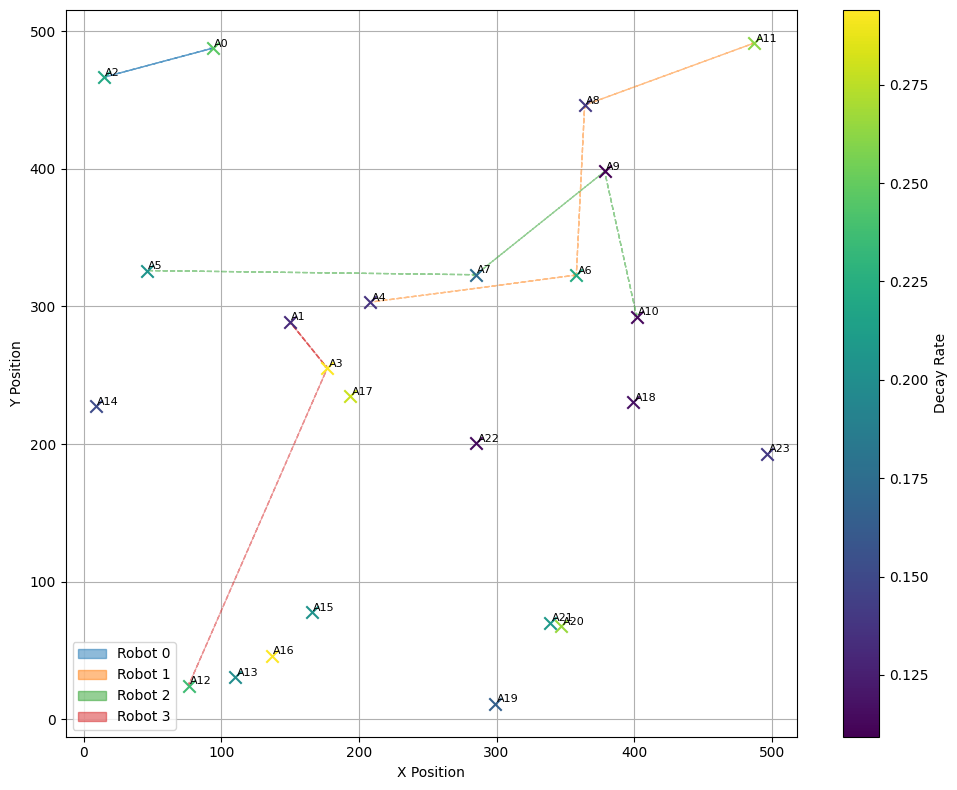

/tmp/ipython-input-671340735.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(decay_cmap)


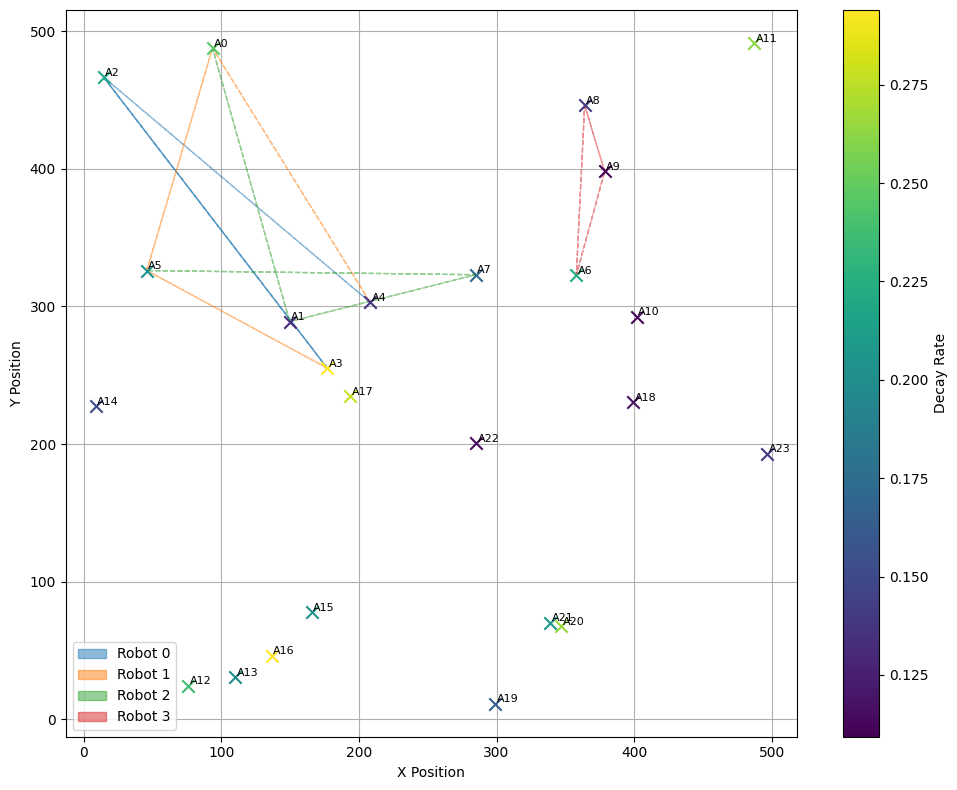

/tmp/ipython-input-671340735.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(decay_cmap)


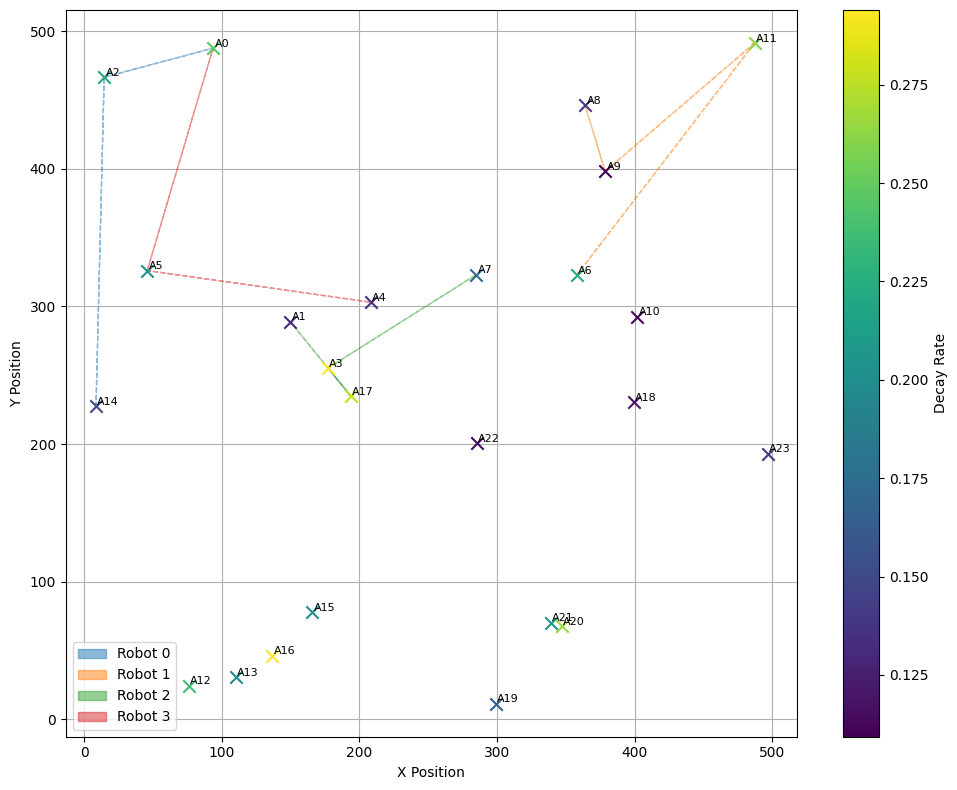

/tmp/ipython-input-671340735.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(decay_cmap)


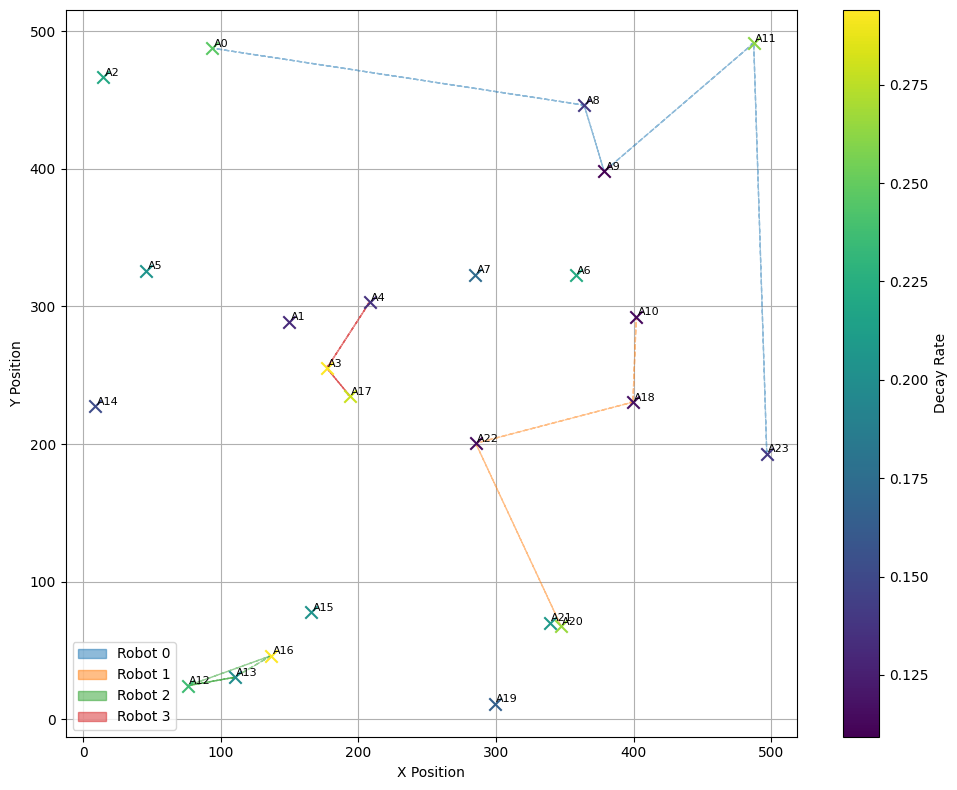

In [ ]:
#Sample one result from random arrangement. Plot their trajectories
compare_star_methods_plot(n_areas=24, n_robots=4, T=2000, seed=42, env_size=(500, 500), decay_range=(0.10, 0.30), arrangement='random')

##Method 6: Clustering with Crisis Mitigation

In [ ]:
import numpy as np
from collections import defaultdict
from typing import List, Dict, Optional, Literal, Tuple, Callable
from sklearn.cluster import KMeans
import math
from math import ceil

In [ ]:
def mean_duration_decay(duration_matrix, area_idx):
    """
    Measures the average duration that an area decays (when robot commits to another decision than restoring area)
    Note that each column of the duration matrix represents that the corresponding area is the decision that the robot is committing to.
    We thus delete the column of the area, and then take the average to measure the average duration.
    :param duration_matrix:
    :param area:
    :return:
    """
    submatrix = np.delete(duration_matrix, area_idx, axis=1)
    return np.mean(submatrix)

In [ ]:
def compute_tau_bar(duration_matrix):
    """
    Returns tau_bar[j] for all areas j, using mean_duration_decay for each column j.
    duration_matrix: J x J, where column j corresponds to 'committing to area j'.
    """
    J = duration_matrix.shape[0]
    tau_bar = np.zeros(J, dtype=float)
    for j in range(J):
        tau_bar[j] = mean_duration_decay(duration_matrix, j)
    return tau_bar

In [ ]:
def _assign_clusters_to_robots(cost: np.ndarray, use_hungarian: bool) -> Dict[int, int]:
    """
    cost[i, j] = distance from robot i to cluster j representative.
    Returns mapping: robot_index -> cluster_index
    """
    Rr, Rc = cost.shape
    if use_hungarian:
        try:
            from scipy.optimize import linear_sum_assignment
            rr, cc = linear_sum_assignment(cost)
            return {int(r): int(c) for r, c in zip(rr, cc)}
        except Exception:
            pass  # fall through to greedy

    # Greedy assignment
    mapping = {}
    used_r, used_c = set(), set()
    pairs = sorted(((cost[i, j], i, j) for i in range(Rr) for j in range(Rc)))
    for _, i, j in pairs:
        if i in used_r or j in used_c:
            continue
        mapping[i] = j
        used_r.add(i); used_c.add(j)
        if len(mapping) == min(Rr, Rc):
            break
    return mapping

In [ ]:
def build_jurisdictions(
    areas: List,
    robots: List,
    alpha_decay: float = 1.0,
    rep: Literal["centroid", "urgent", "medoid"] = "centroid",
    use_hungarian: bool = False,
    seed: Optional[int] = None,) -> Dict[int, List]:
    """
    Cluster areas into R clusters (R = #robots) using sklearn KMeans on features [x, y, alpha_decay*decay_rate],
    then assign clusters to robots by proximity to a cluster representative.

    Args:
        areas: List[Area] with .id, .x, .y, .decay_rate, .F
        robots: List[Robot] with .id, .position = np.array([x, y])
        alpha_decay: scales decay feature in clustering
        rep: cluster representative type for assignment:
             - "centroid": use k-means XY centroid (default)
             - "urgent":   use area with lowest F (tie-break by higher decay)
             - "medoid":   use in-cluster area minimizing sum of distances to others
        use_hungarian: if True and SciPy available, use Hungarian; else greedy
        seed: random_state for KMeans

    Returns:
        Dict[robot_id] -> List[Area] (jurisdiction for each robot)
    """
    R = len(robots)
    if R <= 0:
        raise ValueError("No robots provided.")

    # --- 1) Features: [x, y, alpha*decay] ---
    X = np.array([[a.x, a.y, alpha_decay * float(a.decay_rate)] for a in areas], dtype=float)

    # --- 2) KMeans clustering into R clusters ---
    km = KMeans(n_clusters=R, n_init=10, random_state=seed)
    labels = km.fit_predict(X)                      # shape (J,)
    centers = km.cluster_centers_[:, :2]           # XY centroids for reference

    # --- 3) Build cluster -> areas map ---
    cluster_areas: Dict[int, List] = {cid: [] for cid in range(R)}
    for a, lab in zip(areas, labels):
        cluster_areas[int(lab)].append(a)

    # --- 4) Representative per cluster (for robot-to-cluster distance) ---
    reps_xy = []
    for cid in range(R):
        As = cluster_areas[cid]
        if not As:
            # empty cluster edge-case: fall back to k-means centroid
            reps_xy.append(centers[cid])
            continue

        if rep == "centroid":
            pts = np.array([[a.x, a.y] for a in As], dtype=float)
            reps_xy.append(pts.mean(axis=0))

        elif rep == "urgent":
            # lowest F, tie-break by higher decay_rate
            a_star = min(As, key=lambda a: (a.F, -float(a.decay_rate)))
            reps_xy.append(np.array([a_star.x, a_star.y], dtype=float))

        elif rep == "medoid":
            pts = np.array([[a.x, a.y] for a in As], dtype=float)
            # pairwise L2; medoid = argmin sum of distances
            dmat = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=2)
            m_idx = int(np.argmin(dmat.sum(axis=1)))
            reps_xy.append(pts[m_idx])

        else:
            raise ValueError(f"Unknown rep='{rep}'")

    reps_xy = np.vstack(reps_xy)  # (R,2)

    # --- 5) Build cost matrix: robot i to cluster j representative ---
    cost = np.zeros((R, R), dtype=float)
    for i, r in enumerate(robots):
        for j in range(R):
            cost[i, j] = np.linalg.norm(r.position - reps_xy[j])

    # --- 6) Solve assignment robot->cluster ---
    r2c_idx = _assign_clusters_to_robots(cost, use_hungarian=use_hungarian)

    # --- 7) Build final mapping: robot_id -> list[Area] (jurisdictions) ---
    assignment = defaultdict(list)
    for ri, r in enumerate(robots):
        cid = r2c_idx.get(ri, int(np.argmin(cost[ri])))
        assignment[r.id] = cluster_areas[cid]

    return assignment

#### Crisis predicates

In [ ]:
def decay(rate, t, starting_value):
    """
    Decay function
    :param rate:
    :param t:
    :return:
    """
    decayed_fmeasure = starting_value - (rate * t)
    return decayed_fmeasure

In [ ]:
def will_be_urgent(area, k: int, tau_bar_j: float, z: float = None,
                   g_fn=decay) -> bool:
    """
    Returns True if area j will hit/breach the critical threshold within
    k * tau_bar_j time, assuming no restore until then.
    Uses the *current* F as the starting_value for prediction.
    Parameters
    ----------
    area: Area (must have .decay_rate, .F, and optionally .threshold)
    k: lookahead multiplier (>=1)
    tau_bar_j: average unattended duration proxy for area j
    z: critical threshold; if None, uses area.threshold
    g_fn: decay function rate, t, starting_value -> predicted F
    """
    if z is None:
        z = getattr(area, "threshold", 0.0)
    horizon = max(0.0, k * float(tau_bar_j))
    F_hat = g_fn(float(area.decay_rate), horizon, starting_value=float(area.F))
    return F_hat <= float(z)

In [ ]:
def detect_crisis(areas: List, tau_bar: np.ndarray, k: int, eta: float, R: int,
                  b: int, g_fn=decay, z: float = None) -> Tuple[bool, List, int]:
    """
    Compute crisis condition and return (crisis_flag, rho, Omega_size).
    """
    Omega_size = max(1, int(round(eta * R)))
    rho = [a for a in areas if will_be_urgent(a, k, tau_bar[int(a.id)], z=z, g_fn=g_fn)]
    crisis = (len(rho) >= b * Omega_size)
    return crisis, rho, Omega_size

#### Surge clusters

In [ ]:
RepType = Literal["centroid", "urgent", "medoid"]

In [ ]:
def cluster_urgent_areas(
    rho_areas: List,
    K: int,
    alpha_decay: float = 1.0,
    rep: RepType = "centroid",
    seed: Optional[int] = None,
) -> Tuple[List[List], np.ndarray, Dict[int, Optional[int]]]:
    """
    Cluster the highly-urgent areas rho into K groups using sklearn KMeans on [x, y, alpha_decay*decay_rate].

    Parameters
    ----------
    rho_areas : list[Area]
        Urgent areas (each Area must have .x, .y, .decay_rate, .F, .id).
    K : int
        Number of clusters, typically |Omega|.
    alpha_decay : float
        Scales decay feature in clustering.
    rep : {"centroid","urgent","medoid"}
        Representative for each cluster to use for robot/cluster distance.
    """
    # ---- Edge cases ----
    if K <= 1:
        # Single cluster (or no surge robots): put everything in one bucket
        clusters = [rho_areas[:]]
        # Representative
        if len(rho_areas) == 0:
            rep_xy = np.zeros((1, 2), dtype=float)
            most_urgent_ids = {0: None}
        else:
            if rep == "centroid":
                pts = np.array([[a.x, a.y] for a in rho_areas], dtype=float)
                rep_xy = pts.mean(axis=0, keepdims=True)
            elif rep == "urgent":
                a_star = min(rho_areas, key=lambda a: (a.F, -float(a.decay_rate)))
                rep_xy = np.array([[a_star.x, a_star.y]], dtype=float)
            elif rep == "medoid":
                pts = np.array([[a.x, a.y] for a in rho_areas], dtype=float)
                dmat = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=2)
                m_idx = int(np.argmin(dmat.sum(axis=1)))
                rep_xy = pts[m_idx:m_idx+1]
            else:
                raise ValueError(f"Unknown rep='{rep}'")
            most_urgent_ids = {0: min(rho_areas, key=lambda a: (a.F, -float(a.decay_rate))).id}
        return clusters, rep_xy, most_urgent_ids

    if len(rho_areas) == 0:
        return [[] for _ in range(K)], np.zeros((K, 2), dtype=float), {k: None for k in range(K)}

    # ---- Build feature matrix for KMeans ----
    X = np.array([[a.x, a.y, alpha_decay * float(a.decay_rate)] for a in rho_areas], dtype=float)

    K_eff = min(K, len(rho_areas))

    km = KMeans(n_clusters=K_eff, n_init=10, random_state=seed)
    labels_eff = km.fit_predict(X)  # length = len(rho_areas)

    # Map to K clusters (pad with empties at the end if needed)
    clusters_eff: Dict[int, List] = defaultdict(list)
    for a, lab in zip(rho_areas, labels_eff):
        clusters_eff[int(lab)].append(a)

    clusters_list = [clusters_eff.get(cid, []) for cid in range(K_eff)]
    # Pad to length K
    if K_eff < K:
        clusters_list += [[] for _ in range(K - K_eff)]

    # ---- Representatives per cluster ----
    rep_xy = np.zeros((K, 2), dtype=float)
    most_urgent_ids: Dict[int, Optional[int]] = {cid: None for cid in range(K)}

    for cid in range(K):
        As = clusters_list[cid]
        if not As:
            continue

        if rep == "centroid":
            pts = np.array([[a.x, a.y] for a in As], dtype=float)
            rep_xy[cid] = pts.mean(axis=0)

        elif rep == "urgent":
            a_star = min(As, key=lambda a: (a.F, -float(a.decay_rate)))
            rep_xy[cid] = np.array([a_star.x, a_star.y], dtype=float)
            most_urgent_ids[cid] = a_star.id

        elif rep == "medoid":
            pts = np.array([[a.x, a.y] for a in As], dtype=float)
            dmat = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=2)
            m_idx = int(np.argmin(dmat.sum(axis=1)))
            rep_xy[cid] = pts[m_idx]
            # also record most-urgent id for convenience
            most_urgent_ids[cid] = min(As, key=lambda a: (a.F, -float(a.decay_rate))).id

        else:
            raise ValueError(f"Unknown rep='{rep}'")

        if most_urgent_ids[cid] is None:
            # even for centroid/medoid, keep most-urgent handy
            most_urgent_ids[cid] = min(As, key=lambda a: (a.F, -float(a.decay_rate))).id

    return clusters_list, rep_xy, most_urgent_ids


#### Present value

In [ ]:
def npv_cluster_loss(cluster, z, gamma, delta_t, tau_bar, g_fn):
    """
    Sum over areas j in cluster of discounted loss if left unattended
    for H_j = ceil(|cluster| * tau_bar_j / delta_t) steps, using current F as the start.
    """
    if not cluster:
        return 0.0

    dt = max(1e-9, float(delta_t))
    size = max(1, len(cluster))
    NPV = 0.0

    for a in cluster:
        H = int(ceil(size * float(tau_bar[int(a.id)]) / dt))
        F0 = float(a.F)
        rate = float(a.decay_rate)


        t_h = H * dt
        F_pred = g_fn(rate, t_h, starting_value=F0)
        loss = max(0.0, float(z) - F_pred)
        NPV += (1/(1 + gamma ** H)) * loss

    return float(NPV)


#### Selection of surge robots

In [ ]:
def _robot_area_index(
    r,
    areas: List,
    duration_matrix: np.ndarray,
    cached_idx: Optional[int] = None) -> int:
    """
    Map robot -> current area index for duration lookups.
    Priority:
      1) r.location.id if present
      2) cached_idx if provided
      3) nearest area by Euclidean position (fallback)
    """
    if hasattr(r, "location") and getattr(r.location, "id", None) is not None:
        return int(r.location.id)
    if cached_idx is not None:
        return int(cached_idx)
    # fallback: nearest area by geometry
    pts = np.array([[a.x, a.y] for a in areas], dtype=float)
    d = np.linalg.norm(r.position - pts, axis=1)
    return int(np.argmin(d))

In [ ]:
def select_surge_robots(
    robots: List,
    areas: List,
    jurisdictions: Dict[int, List],          # robot_id -> list[Area] (home cluster)
    rho_areas: List,                          # highly-urgent areas
    Omega_size: int,
    duration_matrix: np.ndarray,              # J x J travel durations (area i -> area j)
    tau_bar: np.ndarray,                      # tau_bar[j] indexed by area.id
    z: float,                                 # critical threshold
    npv_cluster_loss_fn,                      # fn(cluster, z, gamma, delta_t, tau_bar, g_fn) -> float
    g_fn,                                     # decay(rate, t, starting_value)
    gamma: float = 0.98,
    delta_t: float = 1.0,
    home_npv_cache: Optional[Dict[int, float]] = None,
    robot_idx_cache: Optional[Dict[int, int]] = None,
) -> List:
    """
    Select Ω robots to surge.
    Primary sort: home-cluster NPV (ascending).
    """
    Omega_size = max(0, int(Omega_size))
    if Omega_size == 0 or not robots:
        return []

    # 1) Home NPV per robot (with optional cache)
    home_npv = {}
    for r in robots:
        if home_npv_cache is not None and r.id in home_npv_cache:
            home_npv[r.id] = home_npv_cache[r.id]
        else:
            cluster = jurisdictions.get(r.id, [])
            val = float(npv_cluster_loss_fn(cluster, z, gamma, delta_t, tau_bar, g_fn)) if cluster else 0.0
            home_npv[r.id] = val
            if home_npv_cache is not None:
                home_npv_cache[r.id] = val

    # 2) Average duration tie-breaker via duration matrix
    #    Map each urgent area -> its column index
    if rho_areas:
        urgent_idx = np.array([int(a.id) for a in rho_areas], dtype=int)
    else:
        urgent_idx = np.array([], dtype=int)

    avgdur = {}
    for r in robots:
        # get robot's current area index for row lookup
        cached_idx = None if robot_idx_cache is None else robot_idx_cache.get(r.id)
        ri = _robot_area_index(r, areas, duration_matrix, cached_idx=cached_idx)
        if robot_idx_cache is not None:
            robot_idx_cache[r.id] = ri

        if urgent_idx.size > 0:
            # durations from robot's current area to each urgent area
            durs = duration_matrix[ri, urgent_idx]
            avgdur[r.id] = float(np.mean(durs))
        else:
            avgdur[r.id] = 0.0  # neutral if no urgent areas

    # 3) Sort robots by (home_npv asc, avg duration asc, id asc)
    ordered = sorted(robots, key=lambda r: (home_npv[r.id], avgdur[r.id], r.id))
    return ordered[:Omega_size]

#### Crisis mitigation

In [ ]:
import time

In [ ]:
def crisis_callback_builder(
    duration_matrix, areas_init, robots_init, z,
    delta_t: float = 1.0, k: int = 2, eta: float = 0.5, b: int = 1,
    gamma: float = 0.98, alpha_decay: float = 1.0, rep: str = "urgent",
    use_hungarian: bool = False, seed: int | None = None,
):
    tau_bar = compute_tau_bar(duration_matrix)

    # ---- Measure jurisdiction creation ----
    t0 = time.perf_counter()
    jurisdictions = build_jurisdictions(
        areas_init, robots_init,
        alpha_decay=alpha_decay, rep=rep,
        use_hungarian=use_hungarian, seed=seed
    )
    jurisdiction_time = time.perf_counter() - t0
    # ---- End jurisdiction creation ----

    home_npv_cache: dict[int, float] = {}
    robot_idx_cache: dict[int, int] = {}
    surge_bindings: dict[int, dict] = {}

    def _pick_bfvg_next(r, cluster_areas):
        return min(cluster_areas, key=lambda a: a.F) if cluster_areas else None

    def _binding_completed(binding: dict, areas_now) -> bool:
        t_bind = int(binding['t_bind'])
        ids = binding['areas']
        for aid in ids:
            a = next(a for a in areas_now if int(a.id) == int(aid))
            if getattr(a, "last_restore_time", -1) <= t_bind:
                return False
        return True

    def assignments_fn(robots_now, areas_now, t_now: int):
        assign: dict[int, object] = {}

        # ---- Measure crisis detection ----
        t1 = time.perf_counter()
        crisis, rho, Omega_size = detect_crisis(
            areas_now, tau_bar, k, eta,
            len(robots_now), b, g_fn=decay, z=z
        )
        crisis_detection_time = time.perf_counter() - t1
        # ---- End crisis detection ----

        if not crisis:
            surge_bindings.clear()
            for r in robots_now:
                target = _pick_bfvg_next(r, jurisdictions[r.id])
                if target:
                    assign[r.id] = target
            return assign, jurisdiction_time, crisis_detection_time, 0.0

        for rid in list(surge_bindings.keys()):
            if _binding_completed(surge_bindings[rid], areas_now):
                surge_bindings.pop(rid, None)

        Omega_ids = list(surge_bindings.keys())
        if len(Omega_ids) < Omega_size:
            candidates = select_surge_robots(
                robots_now, areas_now, jurisdictions, rho,
                Omega_size=len(robots_now),
                duration_matrix=duration_matrix, tau_bar=tau_bar, z=z,
                gamma=gamma, delta_t=delta_t,
                npv_cluster_loss_fn=npv_cluster_loss, g_fn=decay,
                home_npv_cache=home_npv_cache,
                robot_idx_cache=robot_idx_cache
            )
            for r in candidates:
                if len(Omega_ids) >= Omega_size:
                    break
                if r.id not in Omega_ids:
                    Omega_ids.append(r.id)
        Omega = [next(rr for rr in robots_now if rr.id == rid) for rid in Omega_ids]

        if not Omega or not rho:
            for r in robots_now:
                target = _pick_bfvg_next(r, jurisdictions[r.id])
                if target:
                    assign[r.id] = target
            return assign, jurisdiction_time, crisis_detection_time, 0.0

        # ---- Measure crisis mitigation (3a + 3b) ----
        t2 = time.perf_counter()

        W, _, _ = cluster_urgent_areas(
            rho, len(Omega), alpha_decay=alpha_decay, rep="urgent", seed=seed
        )
        NPV_w = [npv_cluster_loss(wc, z, gamma, delta_t, tau_bar, g_fn=decay)
                 for wc in W]
        cluster_order = list(np.argsort([-v for v in NPV_w]))
        anchors = [(min(wc, key=lambda a: (a.F, -float(a.decay_rate))) if wc else None)
                   for wc in W]

        bound_ids = set(surge_bindings.keys())
        for r in Omega:
            if r.id not in bound_ids:
                continue
            bound_set = surge_bindings[r.id]['areas']
            cluster_areas = [a for a in areas_now if int(a.id) in bound_set]
            target = _pick_bfvg_next(r, cluster_areas)
            if target:
                assign[r.id] = target

        unbound = [r for r in Omega if r.id not in bound_ids]
        if unbound:
            Rm, Km = len(unbound), len(W)
            C = np.full((Rm, Km), np.inf, dtype=float)
            for i, r in enumerate(unbound):
                ri = _robot_area_index(
                    r, areas_now, duration_matrix,
                    cached_idx=robot_idx_cache.get(r.id)
                )
                for j in range(Km):
                    a_anchor = anchors[j]
                    if a_anchor is not None:
                        C[i, j] = duration_matrix[ri, int(a_anchor.id)]
            perm = cluster_order
            C_perm = C[:, perm]
            matched = {}
            try:
                from scipy.optimize import linear_sum_assignment
                rr, cc = linear_sum_assignment(C_perm)
                for i, pj in zip(rr, cc):
                    j = perm[pj]
                    if np.isfinite(C[i, j]):
                        matched[i] = j
            except Exception:
                used_i, used_j = set(), set()
                flat = [(C_perm[i, j], i, j)
                        for i in range(Rm) for j in range(Km)
                        if np.isfinite(C_perm[i, j])]
                for _, i, pj in sorted(flat):
                    if i in used_i:
                        continue
                    j = perm[pj]
                    if j in used_j:
                        continue
                    matched[i] = j
                    used_i.add(i); used_j.add(j)
            for i, j in matched.items():
                r = unbound[i]
                if not W[j]:
                    continue
                surge_bindings[r.id] = {
                    'areas': set(int(a.id) for a in W[j]),
                    't_bind': int(t_now)
                }
                target = _pick_bfvg_next(r, W[j])
                if target:
                    assign[r.id] = target

        surge_id_set = set(Omega_ids)
        for r in robots_now:
            if r.id in surge_id_set:
                continue
            target = _pick_bfvg_next(r, jurisdictions[r.id])
            if target:
                assign[r.id] = target

        crisis_mitigation_time = time.perf_counter() - t2
        # ---- End crisis mitigation ----

        return assign, jurisdiction_time, crisis_detection_time, crisis_mitigation_time

    return assignments_fn


#### Exp 1: Quadrant spatially correlated areas

In [ ]:
n_areas = 24
n_robots = 4
T = 2000
seed = 42

areas, robots = generate_quadrant_star_inputs(
    n_areas=n_areas,
    n_robots=n_robots,
    env_size=(500, 500),
    min_dist=5,
    seed=seed
)

# Fixed clustering
areas_fc, robots_fc = copy.deepcopy(areas), copy.deepcopy(robots)
assignments_fc = fixed_cluster_assignment(areas_fc, robots_fc, n_robots)
areas_result_fc, robots_result_fc = simulate_star(assignments_fc, areas_fc, robots_fc, T=T)

# Fixed clustering w/ Crisis mitigation
areas_cris = copy.deepcopy(areas)
robots_cris = copy.deepcopy(robots)

J = len(areas_cris)
duration_matrix = np.zeros((J, J), dtype=float)
for i, ai in enumerate(areas_cris):
    for j, aj in enumerate(areas_cris):
        duration_matrix[i, j] = np.linalg.norm(ai.position - aj.position)

dyn_fn = crisis_callback_builder(
    duration_matrix=duration_matrix,
    areas_init=areas_cris,
    robots_init=robots_cris,
    z=50.0,            # critical threshold
    delta_t=1.0,
    k=3,               # urgency lookahead multiplier
    eta=1.0,
    b=1,
    gamma=0.75,        # discount
    alpha_decay=1.0,   # weight decay in clustering features
    rep="urgent",
    use_hungarian=True,
    seed=42
)

areas_result_crisis, robots_result_cris, rtime = simulate_star(dynamic_assignment_fn=dyn_fn, areas=areas_cris, robots=robots_cris, T=T, F_max=100.0, velocity=1.0)

In [ ]:
rtime

{'jurisdiction': 0.013014339001529152,
 'crisis_detection': 3.464477817437405e-05,
 'crisis_mitigation': 0.00782747233360068}

Q1: Which one here has the fastest decay rate?


Debugging plot_star_results:
Type of areas: <class 'list'>
Length of areas list: 24
Type of first element in areas: <class '__main__.Area'>
Processing area: <__main__.Area object at 0x7fd5e255ca40>
Processing area: <__main__.Area object at 0x7fd5e2d30500>
Processing area: <__main__.Area object at 0x7fd5e275a8d0>
Processing area: <__main__.Area object at 0x7fd5e27593a0>
Processing area: <__main__.Area object at 0x7fd5f1d8b140>
Processing area: <__main__.Area object at 0x7fd5e1cfaba0>
Processing area: <__main__.Area object at 0x7fd5e1cfb680>
Processing area: <__main__.Area object at 0x7fd5e1cf8350>
Processing area: <__main__.Area object at 0x7fd5e1cfb620>
Processing area: <__main__.Area object at 0x7fd5e1cf9f10>
Processing area: <__main__.Area object at 0x7fd5e1cfb230>
Processing area: <__main__.Area object at 0x7fd5e1cf8530>
Processing area: <__main__.Area object at 0x7fd5e1cfbc80>
Processing area: <__main__.Area object at 0x7fd5e1cf80e0>
Processing area: <__main__.Area object at 0x7fd5

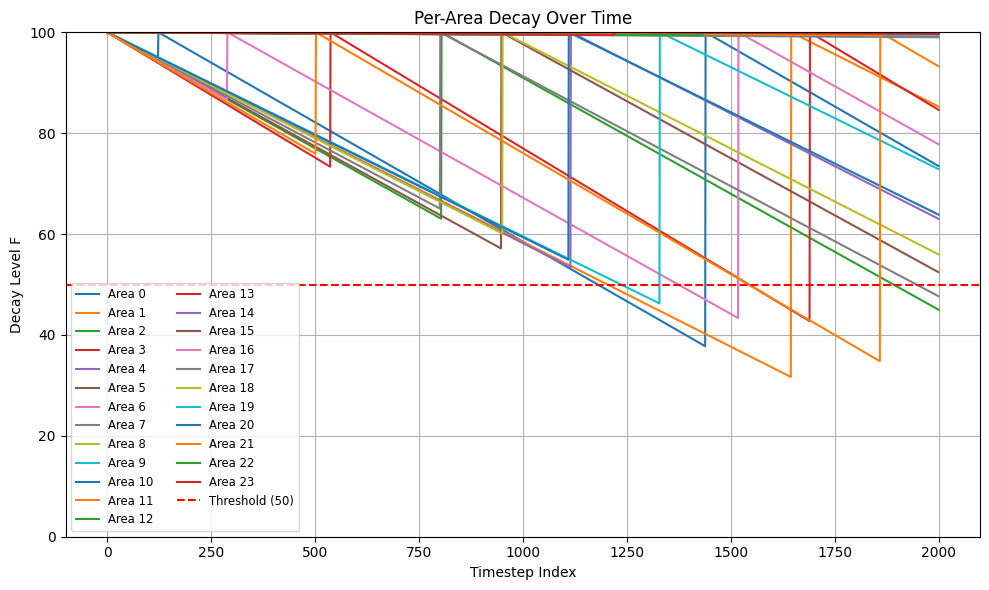

/tmp/ipython-input-473081640.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=robot_ids, y=efficiency, palette="Blues")


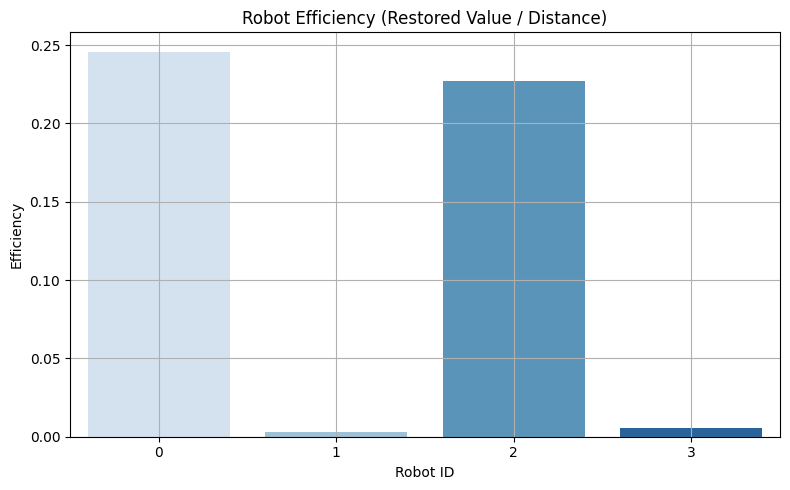

In [ ]:
plot_star_results(areas_result_fc, robots_result_fc)

Debugging plot_star_results:
Type of areas: <class 'list'>
Length of areas list: 24
Type of first element in areas: <class '__main__.Area'>
Processing area: <__main__.Area object at 0x7fd5e2e767e0>
Processing area: <__main__.Area object at 0x7fd5e2e76f00>
Processing area: <__main__.Area object at 0x7fd5e2758650>
Processing area: <__main__.Area object at 0x7fd5e2608320>
Processing area: <__main__.Area object at 0x7fd5eaf63710>
Processing area: <__main__.Area object at 0x7fd5f05c9a30>
Processing area: <__main__.Area object at 0x7fd5eab78c20>
Processing area: <__main__.Area object at 0x7fd5f9aea9c0>
Processing area: <__main__.Area object at 0x7fd5f9aea060>
Processing area: <__main__.Area object at 0x7fd5f9ae8980>
Processing area: <__main__.Area object at 0x7fd5f9aeb740>
Processing area: <__main__.Area object at 0x7fd5e1d6c0e0>
Processing area: <__main__.Area object at 0x7fd5e2fe5460>
Processing area: <__main__.Area object at 0x7fd5e23259a0>
Processing area: <__main__.Area object at 0x7fd5

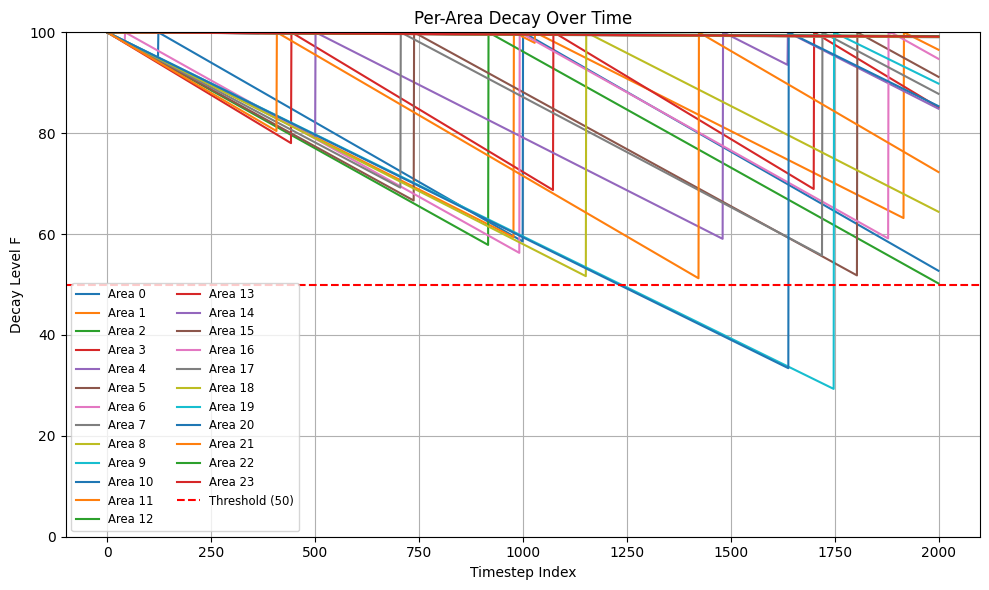

/tmp/ipython-input-473081640.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=robot_ids, y=efficiency, palette="Blues")


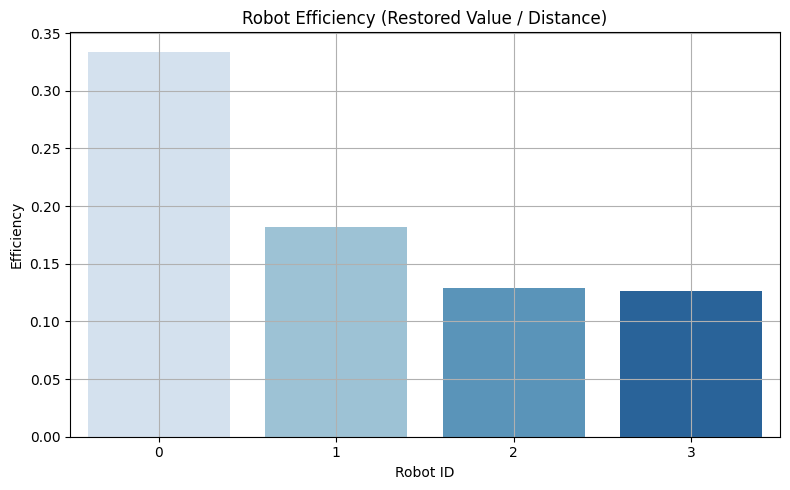

In [ ]:
plot_star_results(areas_result_crisis, robots_result_cris)

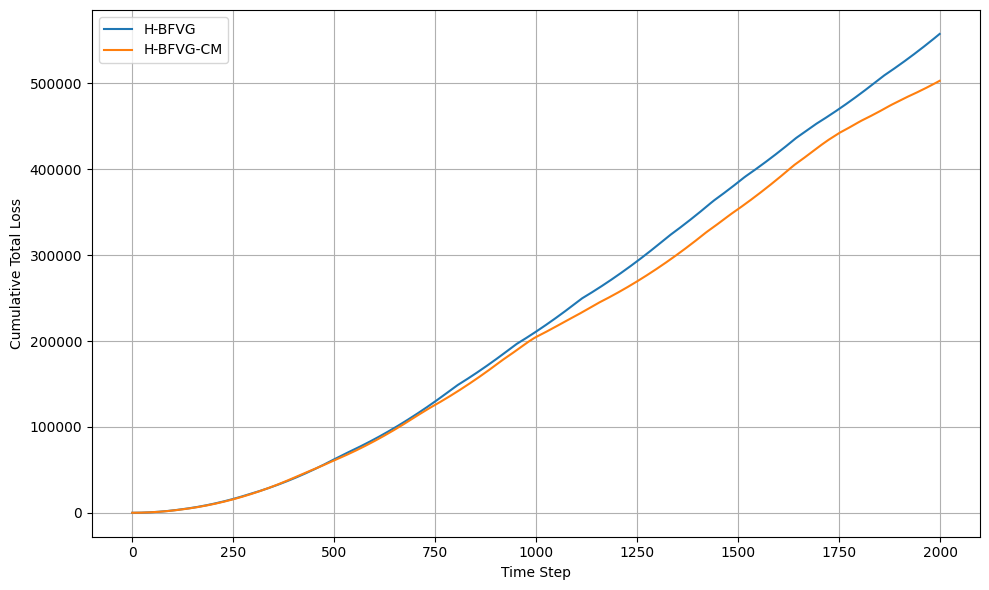

In [ ]:
methods = {}
methods['H-BFVG'] = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_fc))
# methods['Mixed Portfolio'] = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_mp))
methods['H-BFVG-CM'] = compute_cumulative_total_loss(compute_total_loss_from_histories(areas_cris))
# Plot results
plt.figure(figsize=(10,6))
for label, cumulative_loss in methods.items():
    plt.plot(cumulative_loss, label=label)
plt.xlabel("Time Step")
plt.ylabel("Cumulative Total Loss")
# plt.title("Improvement in Performance of Heirarchical Clustering with Crisis Mitigation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('sim_quadrant_24areas_4robots_improvement_crisis_mitigation.pdf', bbox_inches='tight')
plt.show()

#### Robot trajectory

/tmp/ipython-input-671340735.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(decay_cmap)


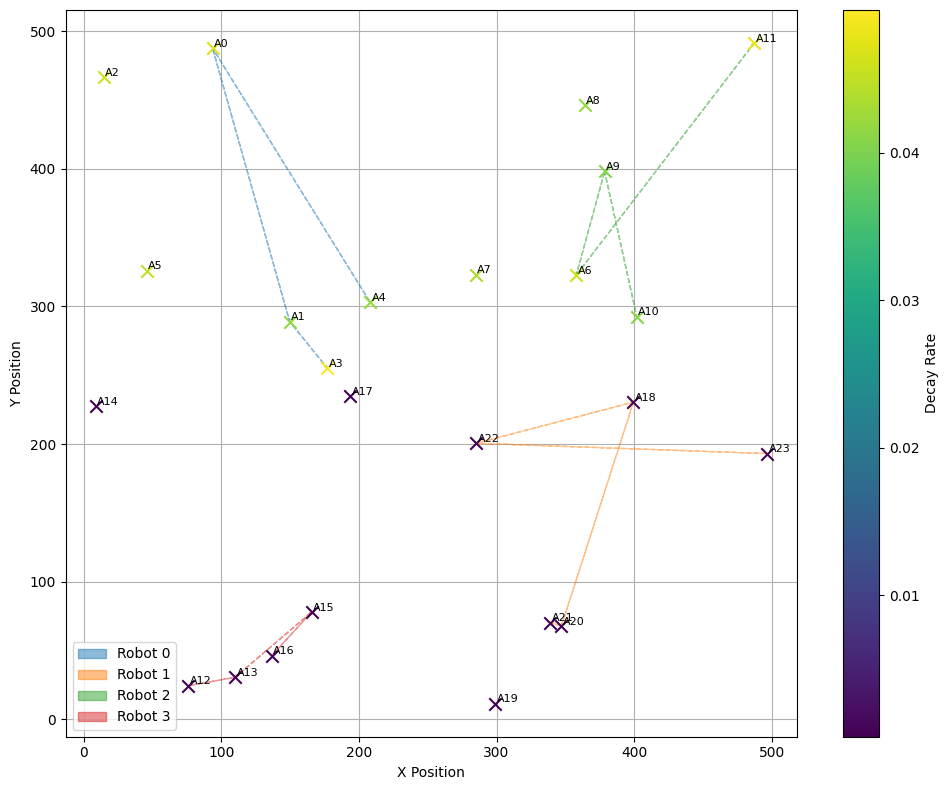

/tmp/ipython-input-671340735.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(decay_cmap)


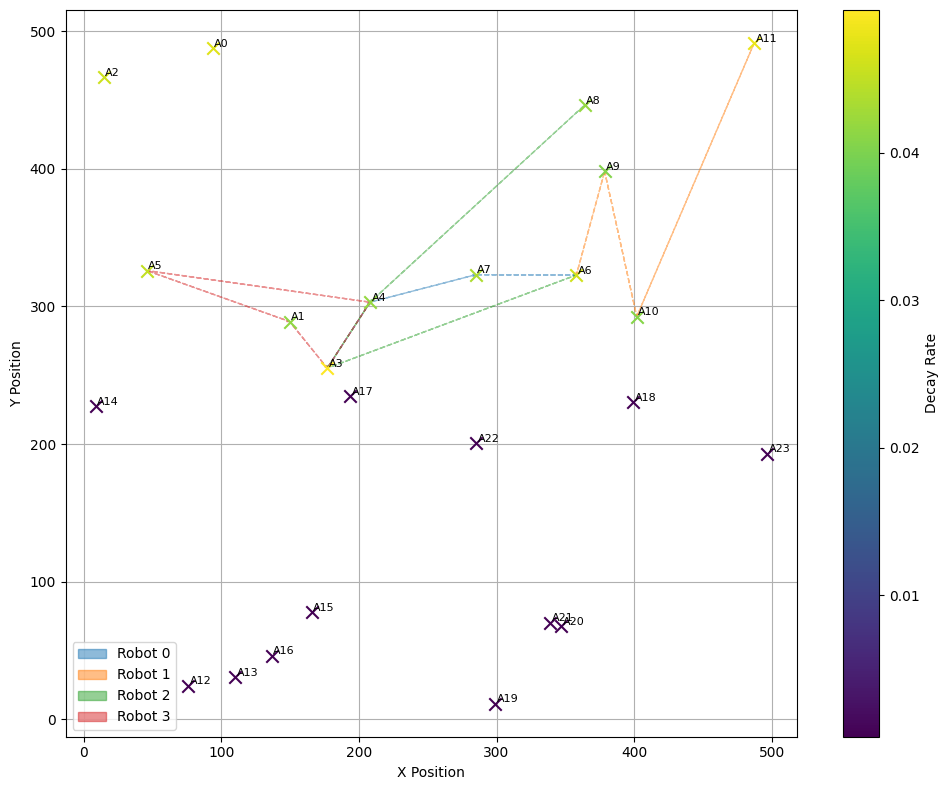

In [ ]:
snapshot = (1000, 2000)
plot_robot_trajectories(robots_result_fc, areas_result_fc, T_snapshot=snapshot, filename='sim_quadrant_24areas_4robots_trajectory_clustering.pdf')
plot_robot_trajectories(robots_result_cris, areas_result_crisis, T_snapshot=snapshot, filename='sim_quadrant_24areas_4robots_trajectory_crisis_mitigation.pdf')

##### Clustering

In [ ]:
max_t = max((t for r in robots_fc for t, _ in r.trajectory), default=100)
interact(lambda t: plot_robot_trajectories_at_time(robots_fc, areas_fc, t), t=(0, max_t, 10))

interactive(children=(IntSlider(value=940, description='t', max=1892, step=10), Output()), _dom_classes=('widg…

<function __main__.<lambda>(t)>

##### Clustering with Crisis Mitigation

In [ ]:
max_t = max((t for r in robots_cris for t, _ in r.trajectory), default=100)
interact(lambda t: plot_robot_trajectories_at_time(robots_cris, areas_cris, t), t=(0, max_t, 10))

interactive(children=(IntSlider(value=990, description='t', max=1996, step=10), Output()), _dom_classes=('widg…

<function __main__.<lambda>(t)>

### Robot frequency by decay class

In [ ]:
from collections import defaultdict

In [ ]:
def plot_robot_visit_frequency_by_decay_class(robots, areas, fast_threshold=0.001):
    """
    Plots the number of visits by each robot to fast- and slow-decaying areas.

    Args:
        robots: List of Robot objects.
        areas: List of Area objects.
        fast_threshold: Threshold decay rate to classify areas as fast or slow decaying.
    """
    # Classify areas
    area_decay_class = {}
    for area in areas:
        area_decay_class[area.id] = 'Fast' if area.decay_rate >= fast_threshold else 'Slow'

    # Count visits
    visit_counts = defaultdict(lambda: {'Fast': 0, 'Slow': 0})
    for r in robots:
        for _, area_id in r.trajectory:
            decay_class = area_decay_class.get(area_id)
            if decay_class:
                visit_counts[r.id][decay_class] += 1

    # Prepare data
    robot_ids = sorted(visit_counts.keys())
    fast_visits = [visit_counts[rid]['Fast'] for rid in robot_ids]
    slow_visits = [visit_counts[rid]['Slow'] for rid in robot_ids]

    x = np.arange(len(robot_ids))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, fast_visits, width, label='Fast Decay', color='orangered')
    plt.bar(x + width/2, slow_visits, width, label='Slow Decay', color='skyblue')
    plt.xlabel("Robot ID")
    plt.ylabel("Number of Visits")
    plt.title("Visit Frequency by Decay Class per Robot")
    plt.xticks(x, [f"R{rid}" for rid in robot_ids])
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

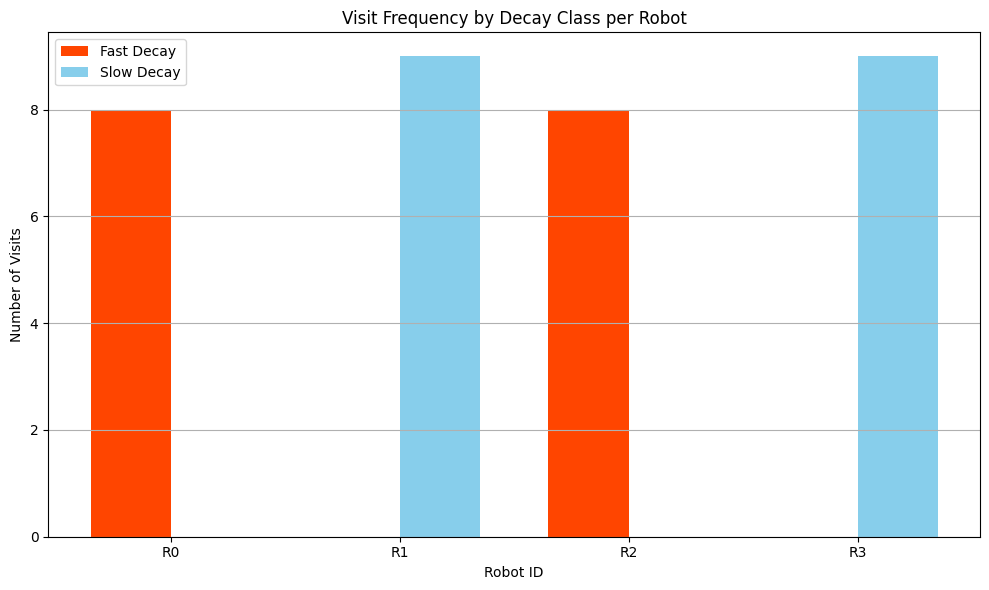

In [ ]:
plot_robot_visit_frequency_by_decay_class(robots_result_fc, areas_result_fc)

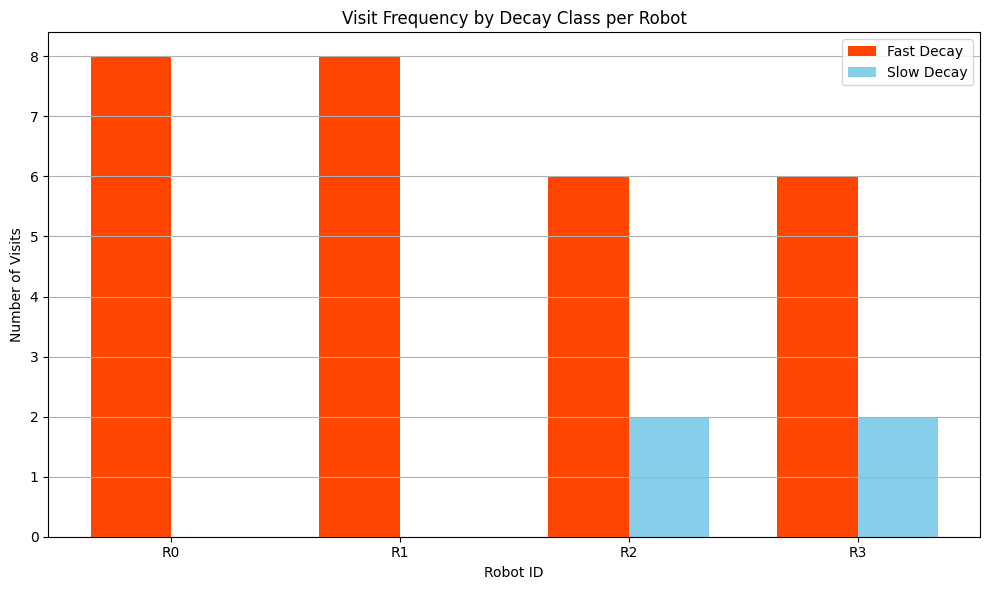

In [ ]:
plot_robot_visit_frequency_by_decay_class(robots_result_cris, areas_result_crisis)

## Scalability

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from concurrent.futures import ThreadPoolExecutor, TimeoutError

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
drive_folder_path = '/content/drive/My Drive/multi_STAR_sim_results'
os.chdir(drive_folder_path)
print(f"Current working directory: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current working directory: /content/drive/My Drive/multi_STAR_sim_results


In [ ]:
# CONFIGURATION
MAX_RUNTIME = 120
N_VALUES = [10, 10**2, 10**3, 10**4]
M_VALUES = [10, 10**2, 10**3, 10**4]

results = {
    "juris_clust": {m: [] for m in M_VALUES},
    "crisis_detect": {m: [] for m in M_VALUES},
    "mitig_clust": {m: [] for m in M_VALUES},
    "assign_hungarian": {m: [] for m in M_VALUES},
    "assign_greedy": {m: [] for m in M_VALUES}
}
executor = ThreadPoolExecutor(max_workers=1)

In [ ]:
# DUMMY DATA GENERATOR
def generate_star_inputs(n, m):
    class Area:
        def __init__(self, i):
            self.id = i
            self.position = np.random.rand(2)
            self.decay_rate = np.random.rand() * 0.3
            self.F = np.random.rand() * 100
    class Robot:
        def __init__(self, i):
            self.id = i
            self.position = np.random.rand(2)
    areas = [Area(i) for i in range(n)]
    robots = [Robot(i) for i in range(m)]
    duration_matrix = np.random.rand(n, n)
    return areas, robots, duration_matrix

In [ ]:
# TIMING FUNCTIONS
def measure_jurisdiction_clustering_time(areas, robots, duration_matrix):
    # Simulate K-means cost ~ O(n*m)
    n, m = len(areas), len(robots)
    X = np.random.rand(n, 3)
    start = time.perf_counter()
    # simple Lloyd iterations
    C = X[np.random.choice(n, m, replace=False)]
    for _ in range(5):
        d = np.linalg.norm(X[:, None, :] - C[None, :, :], axis=2)
        labels = np.argmin(d, axis=1)
        for j in range(m):
            if np.any(labels == j):
                C[j] = X[labels == j].mean(axis=0)
    return time.perf_counter() - start

In [ ]:
def measure_crisis_detection_time(areas, robots, duration_matrix):
    n, m = len(areas), len(robots)
    start = time.perf_counter()
    # O(n + m^2) dummy workload
    _ = np.sum(duration_matrix)           # simulate per-area scan
    _ = np.random.rand(m, m) @ np.random.rand(m, m)
    return time.perf_counter() - start

In [ ]:
def measure_mitigation_clustering_time(areas, robots, duration_matrix):
    n, m = len(areas), len(robots)
    urgent = np.random.rand(min(1000, n), 3)   # subset urgent
    start = time.perf_counter()
    C = urgent[np.random.choice(len(urgent), min(m, len(urgent)), replace=False)]
    for _ in range(5):
        d = np.linalg.norm(urgent[:, None, :] - C[None, :, :], axis=2)
        labels = np.argmin(d, axis=1)
        for j in range(len(C)):
            if np.any(labels == j):
                C[j] = urgent[labels == j].mean(axis=0)
    return time.perf_counter() - start

In [ ]:
def measure_assignment_time(areas, robots, duration_matrix, method="hungarian"):
    m = len(robots)
    k = len(robots)
    C = np.random.rand(m, k)
    start = time.perf_counter()
    if method == "hungarian":
        from scipy.optimize import linear_sum_assignment
        rr, cc = linear_sum_assignment(C)
        _ = list(zip(rr, cc))
    else:  # greedy
        flat = sorted([(C[i, j], i, j) for i in range(m) for j in range(k)])
        used_i, used_j = set(), set()
        assign = []
        for _, i, j in flat:
            if i in used_i or j in used_j: continue
            assign.append((i, j))
            used_i.add(i); used_j.add(j)
    return time.perf_counter() - start

In [ ]:
# MAIN SCALABILITY LOOP
for m in M_VALUES:
    for n in N_VALUES:
          try:
              jc, cd, mc, ah, ag = np.nan, np.nan, np.nan, np.nan, np.nan
              if n >= m:
                print(f"▶ Running scalability test for n={n}, m={m}")
                areas, robots, duration_matrix = generate_star_inputs(n, m)

                # Jurisdiction clustering
                future = executor.submit(measure_jurisdiction_clustering_time, areas, robots, duration_matrix)
                jc = future.result(timeout=MAX_RUNTIME)

                # Crisis detection
                future = executor.submit(measure_crisis_detection_time, areas, robots, duration_matrix)
                cd = future.result(timeout=MAX_RUNTIME)

                # Mitigation clustering
                future = executor.submit(measure_mitigation_clustering_time, areas, robots, duration_matrix)
                mc = future.result(timeout=MAX_RUNTIME)

                # Assignment Hungarian
                future = executor.submit(measure_assignment_time, areas, robots, duration_matrix, "hungarian")
                ah = future.result(timeout=MAX_RUNTIME)

                # Assignment Greedy
                future = executor.submit(measure_assignment_time, areas, robots, duration_matrix, "greedy")
                ag = future.result(timeout=MAX_RUNTIME)

              results["juris_clust"][m].append(jc)
              results["crisis_detect"][m].append(cd)
              results["mitig_clust"][m].append(mc)
              results["assign_hungarian"][m].append(ah)
              results["assign_greedy"][m].append(ag)

              print(f"   ✅ jc={jc:.4f}s, cd={cd:.4f}s, mc={mc:.4f}s, AH={ah:.4f}s, AG={ag:.4f}s")

          except TimeoutError:
              print(f"   ⏹ Timeout at n={n}, m={m}")
              for key in results.keys():
                  # Append NaN for the current n value for all remaining m values
                  results[key][m].extend([np.nan] * (len(N_VALUES) - len(results[key][m])))
              break

▶ Running scalability test for n=10, m=10
   ✅ jc=0.0049s, cd=0.0003s, mc=0.0022s, AH=0.0001s, AG=0.0002s
▶ Running scalability test for n=100, m=10
   ✅ jc=0.0022s, cd=0.0001s, mc=0.0019s, AH=0.0000s, AG=0.0001s
▶ Running scalability test for n=1000, m=10
   ✅ jc=0.0054s, cd=0.0010s, mc=0.0050s, AH=0.0001s, AG=0.0001s
▶ Running scalability test for n=10000, m=10
   ✅ jc=0.0340s, cd=0.0764s, mc=0.0052s, AH=0.0001s, AG=0.0002s
   ✅ jc=nans, cd=nans, mc=nans, AH=nans, AG=nans
▶ Running scalability test for n=100, m=100
   ✅ jc=0.0151s, cd=0.0007s, mc=0.0196s, AH=0.0007s, AG=0.0233s
▶ Running scalability test for n=1000, m=100
   ✅ jc=0.0420s, cd=0.0015s, mc=0.0406s, AH=0.0005s, AG=0.0144s
▶ Running scalability test for n=10000, m=100
   ✅ jc=0.2862s, cd=0.0746s, mc=0.0387s, AH=0.0006s, AG=0.0115s
   ✅ jc=nans, cd=nans, mc=nans, AH=nans, AG=nans
   ✅ jc=nans, cd=nans, mc=nans, AH=nans, AG=nans
▶ Running scalability test for n=1000, m=1000
   ✅ jc=0.3864s, cd=0.0368s, mc=0.4139s, AH=0.0957

In [ ]:
# SAVE RESULTS
rows = []
for key, dict_m in results.items():
    for m, vals in dict_m.items():
        for n, v in zip(N_VALUES, vals):
            rows.append({"phase": key, "n": n, "m": m, "runtime": v})
df = pd.DataFrame(rows)
df.to_csv("star_scalability_results.csv", index=False)
print("💾 Results saved to star_scalability_results.csv")

💾 Results saved to star_scalability_results.csv


In [ ]:
# PLOTTING
titles = [
    "Jurisdiction Creation",
    "Crisis Detection",
    "Crisis Mitigation",
    "Assignment (Hungarian)",
    "Assignment (Greedy)"
]
keys = ["juris_clust", "crisis_detect", "mitig_clust", "assign_hungarian", "assign_greedy"]

for title, key in zip(titles, keys):
    plt.figure(figsize=(7, 5))
    for m, times in results[key].items():
        padded_times = times + [np.nan] * (len(N_VALUES) - len(times))
        plt.plot(N_VALUES, padded_times, marker='o', label=f"m={m}")

    plt.xscale('log')
    plt.yscale('log')
    plt.xticks(N_VALUES, labels=[str(v) for v in N_VALUES])
    plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
    plt.xlabel("Number of Areas (n)")
    plt.ylabel("Runtime (seconds)")
    # plt.title(f"{title} Scalability")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()

    filename = f"Scalability_{title.replace(' ', '_')}.pdf"
    plt.savefig(filename, bbox_inches='tight')
    print(f"💾 Saved {filename}")

    plt.close()


💾 Saved Scalability_Jurisdiction_Creation.pdf
💾 Saved Scalability_Crisis_Detection.pdf
💾 Saved Scalability_Crisis_Mitigation.pdf
💾 Saved Scalability_Assignment_(Hungarian).pdf
💾 Saved Scalability_Assignment_(Greedy).pdf
